print('Unique regions in df_pib_for_map:', df_pib_for_map['Región'].unique())

geonames_in_geojson = [feature['properties']['name'] for feature in geojson_data['objects']['cl']['geometries']]
print('Unique region names in GeoJSON:', sorted(list(set(geonames_in_geojson))))

# Análisis Económico Regional de Chile (2013–2024)
**Fuente:** Banco Central de Chile — API `bcchapi`

## Contexto y Motivación

Chile es un país geográficamente diverso, con regiones cuya base
económica se ha entrado en discucion en los ultimos años: desde la minería del cobre en el norte
hasta la pesca y el turismo en el sur. Sin embargo, gran parte del
debate económico nacional se concentra en cifras agregadas que ocultan
las diferencias regionales.

Este proyecto nace de la siguiente pregunta:

> **¿Que regiones de Chile están creciendo más y qué factores
> explican ese crecimiento? y ¿Que sectores son los principales contribuyentes al PIB del pais?**

Para responderla, se utilizaron datos oficiales del Banco Central de
Chile, analizando el PIB anual de las 16 regiones y sus sectores
productivos entre 2013 y 2024. El análisis busca identificar patrones
de crecimiento, anticipar cambios estructurales en la economía regional
y entender cómo eventos como la pandemia COVID-19 afectaron de forma
diferenciada a cada territorio.

Como variable complementaria, se incorporaron datos de generación
eléctrica regional para explorar si la actividad energética anticipa
o sigue al crecimiento económico.

# Lectura de datos

##Librerias python y banco central

In [318]:
pip install bcchapi

In [319]:
import bcchapi
import requests
import numpy as np
import pandas as pd
from scipy.stats import linregress, shapiro, pearsonr, spearmanr
import matplotlib.pyplot as plt

In [320]:
import geopandas as gpd
import plotly.express as px

### Prueba rapida de datasets

In [321]:
siete = bcchapi.Siete(file="user.txt")

In [322]:
siete.buscar("Electricidad").spanishTitle.unique()

array(['Electricidad, Gas y Agua | Colocaciones por actividad económica, cifras oficiales de la CMF  |  | Stock | Mensual | Millones de pesos chilenos | Comisión para el mercado financiero (CMF) | ',
       'Cesantes por rama de actividad económica, Suministro de electricidad, gas, vapor y aire acondicionado, INE (NENE), promedios móviles trimestrales, miles de personas',
       'Desocupados electricidad, gas y agua, mensual, INE ',
       'Cesantes suministro de electricidad, gas y agua, mensual, INE',
       'Ocupados electricidad, gas y agua, mensual, INE (promedios móviles trimestrales, miles de personas)  ',
       'Ocupación por rama de actividad económica, Suministro de electricidad, gas, vapor y aire acondicionado, INE (NENE), promedios móviles trimestrales, miles de personas',
       'Ocupados suministro de electricidad, gas y agua, mensual, INE',
       'Remuneraciones electricidad, gas y agua mensual, INE ',
       'IPM Productos nacionales, suministro electricidad, gas y ag

In [323]:
df_arica=siete.buscar("Región de Arica")

In [324]:
df_arica.frequencyCode.unique()

array(['MONTHLY', 'QUARTERLY', 'DAILY', 'ANNUAL'], dtype=object)

In [325]:
lista_dataset= ["Tasa de desocupación, ", 'Empleo: ', ]
lista_electrcidad = ['Generación eléctrica, MWh; ','Distribución eléctrica, MWh;']
lista_turismo = ["Encuesta mensual de alojamiento turístico (EMAT)"]
lista_servicios_quar = [", volumen a precios del año anterior encadenado, referencia 2018 (miles de millones de pesos encadenados)"]
lista_servicios_anuales = [' precios corrientes, base 2018']

lista_empresa = [ 'Región de Arica y Parinacota, Número de constituciones en registro de empresas y sociedades a nivel regional; mensual;  cantidad; MINECON']
lista_cc ={'Saldo promedio de cuentas corrientes de personas naturales en moneda extranjera;',
       'Saldo promedio de cuentas corrientes de personas naturales en moneda nacional;','Número de cuentas corrientes de personas naturales en moneda extranjera; ', 'Número de cuentas corrientes de personas naturales en moneda nacional;'}

In [326]:
df_arica[df_arica.frequencyCode == "ANNUAL"].spanishTitle.unique();

##Nota


Los años indican los acumulado entre el 1 de enero al 31 de diciembre

# Regiones y servicios

## Carga de datos

### PIB por Región y Servicio Anual

In [327]:
lista_servicios_anuales[0]

' precios corrientes, base 2018'

In [328]:
df_servicios_per_region = siete.buscar(lista_servicios_anuales[0])

In [329]:
def ajuste_df_serie(df_per_region):
  df_temp = df_per_region.copy()
  df_temp [["Titulo","Región"]]=df_temp.spanishTitle.str.split(" Región ",expand=True)
  df_temp['Región'] = df_temp['Región'].str.split(",",n=1,expand=True)[0]
  df_temp['Región'] = df_temp['Región'].str.replace("de ","")
  df_temp['Región'] = df_temp['Región'].str.strip()

  df_temp['Titulo'] = df_temp['Titulo'].str.replace(",","")
  df_temp['Titulo'] = df_temp['Titulo'].str.strip()
  return df_temp

In [330]:
df_servicios_per_region = ajuste_df_serie(df_servicios_per_region)
df_servicios_per_region.Titulo.unique()

array(['PIB subtotal regionalizado precios corrientes base 2018 (miles de millones de pesos)',
       'PIB Agropecuario-silvícola', 'PIB Pesca', 'PIB Minería',
       'PIB Industria manufacturera', 'PIB Electricidad gas y agua',
       'PIB Construcción', 'PIB Transportes y comunicaciones',
       'PIB Servicios financieros y empresariales',
       'PIB Propiedad de vivienda', 'PIB Servicios de vivienda',
       'PIB Servicios personales', 'PIB Administración pública',
       'PIB Comercio', 'PIB Comercio restaurantes y hotele',
       'PIB Restaurantes y hoteles', 'PIB',
       'Extrarregional precios corrientes base 2018 (miles de millones de pesos)'],
      dtype=object)

In [331]:
def datos_regionales(df_servicios_per_region):
  dfs_serv_reg=[]
  url = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"
  df_temp = df_servicios_per_region.reset_index()
  for idx, serie in enumerate(df_temp.seriesId.values):

    params = {
        "user": "rodolfo.godoyarteaga@gmail.com",
        "pass": "Chihuahua12",
        "function": "GetSeries",
        "timeseries": serie,
        "firstdate": "2000-01-01",
        "lastdate": "2026-01-01"
    }
    response = requests.get(url, params=params).json()

    try:
        df = pd.DataFrame(response["Series"]["Obs"])

        df["Titulo"] = df_temp["Titulo"][idx]

        df['Región'] = df_temp["Región"][idx]

        #df_temp = pd.json_normalize(df["Obs"])
        #df = pd.concat([df, df_temp], axis=1)

        #df["value"] = df["Obs"].value.astype(float)

        dfs_serv_reg.append(df)
    except:
        print(f"Error en serie {serie}")

  df_final = pd.concat(dfs_serv_reg)

  df_final["Región"] = df_final['Región'].str.strip()
  df_final["Región"] = df_final['Región'].str.capitalize()
  df_final["value"]  = df_final["value"].astype(float)
  df_final['indexDateString'] = pd.to_datetime(df_final['indexDateString'])
  df_final.rename(columns = {'indexDateString':'Date'}, inplace= True)
  #df_final["Date"] = df_final["Date"].dt.strftime('%d-%m-%Y')
  return df_final

In [332]:
df_anual = datos_regionales(df_servicios_per_region)
df_anual.Región.unique()

array([None, 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo',
       'Valparaíso', 'Del libertador general bernardo ohiggins',
       'Del maule', 'Del biobío', 'La araucanía', 'Los lagos',
       'Aysén del general carlos ibáñez del campo',
       'Magallanes y la antártica chilena', 'Metropolitana santiago',
       'Los ríos', 'Arica y parinacota', 'Del ñuble'], dtype=object)

In [333]:
df_anual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2712 entries, 0 to 11
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2712 non-null   datetime64[ns]
 1   value       2712 non-null   float64       
 2   statusCode  2712 non-null   object        
 3   Titulo      2712 non-null   object        
 4   Región      2688 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 127.1+ KB


### PIB por Región Quatrimestre

In [334]:
x= siete.buscar("PIB region")
x[x.frequencyCode == "QUARTERLY"].spanishTitle.unique()

array(['PIB Regional, Región de Tarapacá, contribución porcentual respecto de igual periodo del año anterior, referencia 2018 (Porcentaje)',
       'PIB Regional, Región de Antofagasta, contribución porcentual respecto de igual periodo del año anterior, referencia 2018 (Porcentaje)',
       'PIB Regional, Región de Atacama, contribución porcentual respecto de igual periodo del año anterior, referencia 2018 (Porcentaje)',
       'PIB Regional, Región de Coquimbo, contribución porcentual respecto de igual periodo del año anterior, referencia 2018 (Porcentaje)',
       'PIB Regional, Región de Valparaíso, contribución porcentual respecto de igual periodo del año anterior, referencia 2018 (Porcentaje)',
       'PIB Regional, Región de Libertador General Bernardo O`Higgins, contribución porcentual respecto de igual periodo del año anterior, referencia 2018 (Porcentaje)',
       'PIB Regional, Región del Maule, contribución porcentual respecto de igual periodo del año anterior, referencia 20

In [335]:
x =siete.buscar("referencia 2018")


In [336]:
from sklearn.preprocessing import OrdinalEncoder

In [337]:
def ajuste_df_serie_quartely(df_per_region):
  df_temp = df_per_region.copy()
  ordinal_encoder = OrdinalEncoder()
  df_temp [["Titulo","Región"]]=df_temp.spanishTitle.str.split(" Región ",expand=True)
  df_temp = df_temp[(df_temp["Titulo"]=="PIB") & (df_temp["frequencyCode"]=="QUARTERLY")]
  df_temp[["Región","Tipo"]] = df_temp['Región'].str.split(",",n=1,expand=True)


  df_temp['Región'] = df_temp['Región'].str.split(",",n=1,expand=True)[0]
  df_temp['Región'] = df_temp['Región'].str.replace("de ","")
  df_temp['Región'] = df_temp['Región'].str.strip()

  df_temp['Titulo'] = df_temp['Titulo'].str.replace(",","")
  df_temp['Titulo'] = df_temp['Titulo'].str.strip()

  df_temp["id_tipo"] = ordinal_encoder.fit_transform(df_temp["Tipo"].to_frame())
  return df_temp

In [338]:
df_pib_quartely = ajuste_df_serie_quartely(x)

In [339]:
def datos_regionales_quartely(df_per_region,tipo):
  dfs_serv_reg=[]
  df_temp = df_per_region[df_per_region["id_tipo"] == tipo]
  df_temp = df_temp.reset_index()
  url = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"
  tipo_selecionado = df_per_region[df_per_region["id_tipo"]==tipo]["Tipo"].unique()[0]
  print(f"El tipo de PIB que se eligio fue {tipo_selecionado}")
  for idx, serie in enumerate(df_temp.seriesId.values):

    params = {
        "user": "rodolfo.godoyarteaga@gmail.com",
        "pass": "Chihuahua12",
        "function": "GetSeries",
        "timeseries": serie,
        "firstdate": "2000-01-01",
        "lastdate": "2027-07-01"
    }
    response = requests.get(url, params=params).json()

    try:
        df = pd.DataFrame(response["Series"]["Obs"])

        df["Titulo"] = df_temp["Titulo"][idx]

        df['Región'] = df_temp["Región"][idx]

        #df_temp = pd.json_normalize(df["Obs"])
        #df = pd.concat([df, df_temp], axis=1)

        #df["value"] = df["Obs"].value.astype(float)

        dfs_serv_reg.append(df)
    except:
        print(f"Error en serie {serie}")
  df_final = pd.concat(dfs_serv_reg)

  df_final["Región"] = df_final['Región'].str.strip()
  df_final["Región"] = df_final['Región'].str.capitalize()
  df_final["value"]  = df_final["value"].astype(float)
  df_final['indexDateString'] = pd.to_datetime(df_final['indexDateString'])
  df_final.rename(columns = {'indexDateString':'Date'}, inplace= True)
  #df_final["Date"] = df_final["Date"].dt.strftime('%d-%m-%Y')
  return df_final

In [340]:
df_quartely = datos_regionales_quartely(df_pib_quartely,1.0)

El tipo de PIB que se eligio fue  volumen a precios del año anterior encadenado, referencia 2018 (miles de millones de pesos encadenados)


In [341]:
df_quartely

,Date,value,statusCode,Titulo,Región
0,2013-01-01,827.462051,OK,PIB,Tarapacá
1,2013-01-04,939.435685,OK,PIB,Tarapacá
2,2013-01-07,1054.792897,OK,PIB,Tarapacá
3,2013-01-10,1152.210139,OK,PIB,Tarapacá
4,2014-01-01,983.978697,OK,PIB,Tarapacá
...,...,...,...,...,...
46,2024-01-07,726.534416,OK,PIB,Ñuble
47,2024-01-10,846.126386,OK,PIB,Ñuble
48,2025-01-01,849.087156,OK,PIB,Ñuble
49,2025-01-04,812.243706,OK,PIB,Ñuble


###PIB por Region porcentaje

In [342]:
x = siete.buscar("contribución porcentual respecto de igual periodo del año anterior, referencia 2018")
x = x[(x.spanishTitle.str.contains("PIB Región")) & (x.frequencyCode == "QUARTERLY")]

In [343]:
df_pib_and_activity_porc = ajuste_df_serie(x)

In [344]:
df_porc = datos_regionales(df_pib_and_activity_porc)

In [345]:
df_porc

,Date,value,statusCode,Titulo,Región
0,2014-01-01,0.389429,OK,PIB,Tarapacá
1,2014-01-04,0.143768,OK,PIB,Tarapacá
2,2014-01-07,-0.246316,OK,PIB,Tarapacá
3,2014-01-10,-0.141502,OK,PIB,Tarapacá
4,2015-01-01,-0.028896,OK,PIB,Tarapacá
...,...,...,...,...,...
42,2024-01-07,0.015248,OK,PIB,Ñuble
43,2024-01-10,0.072177,OK,PIB,Ñuble
44,2025-01-01,0.049192,OK,PIB,Ñuble
45,2025-01-04,0.055818,OK,PIB,Ñuble


# Analisis Descriptivo

In [346]:
df_anual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2712 entries, 0 to 11
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2712 non-null   datetime64[ns]
 1   value       2712 non-null   float64       
 2   statusCode  2712 non-null   object        
 3   Titulo      2712 non-null   object        
 4   Región      2688 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 127.1+ KB


In [347]:
df_anual = df_anual.drop(columns=["statusCode"])
df_final_servicios = df_anual[df_anual['Región'].isna()==False]
df_final_servicios = df_final_servicios[df_final_servicios['Titulo'] != "PIB"]
df_final_servicios = df_final_servicios.reset_index()

##Analisis Por Región

**¿Cuáles son los tres servicios que más aportan al PIB de cada región?**
**¿Qué sectores productivos dominan a nivel nacional en el período
2013–2024?**

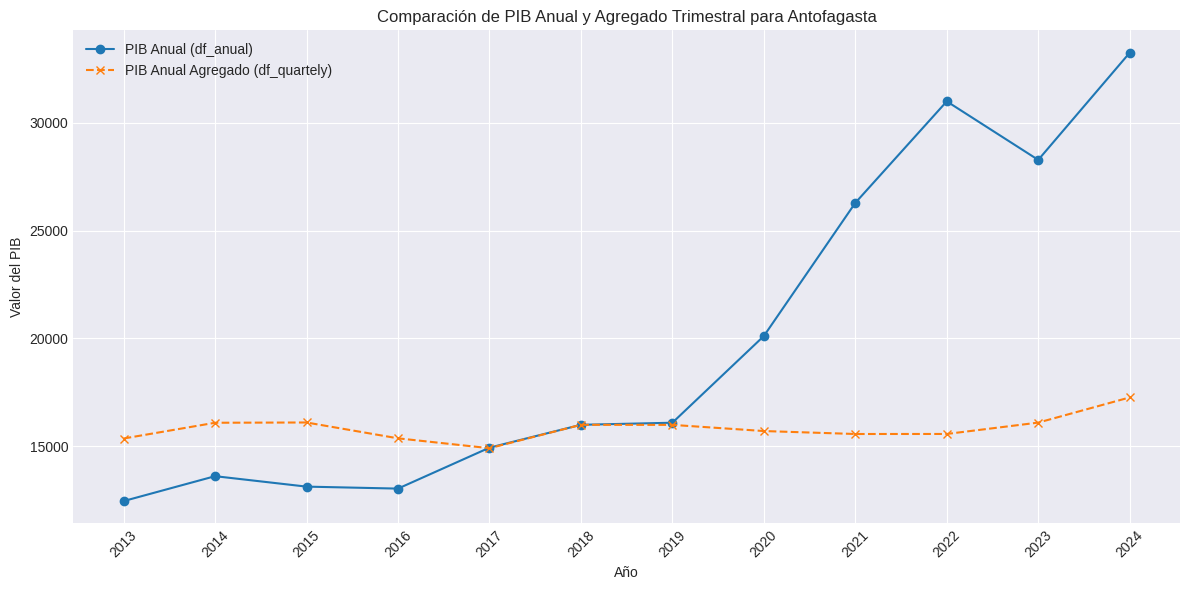

In [348]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter annual PIB data for Antofagasta
df_pib_annual_antofagasta = df_anual[(df_anual['Región'] == 'Antofagasta') & (df_anual['Titulo'] == 'PIB')].copy()
df_pib_annual_antofagasta['Year'] = df_pib_annual_antofagasta['Date'].dt.year

# Filter quarterly PIB data for Antofagasta and aggregate to annual
df_pib_quartely_antofagasta = df_quartely[(df_quartely['Región'] == 'Antofagasta') & (df_quartely['Titulo'] == 'PIB')].copy()
df_pib_quartely_antofagasta['Year'] = df_pib_quartely_antofagasta['Date'].dt.year
df_pib_quartely_annual_agg = df_pib_quartely_antofagasta.groupby('Year')['value'].sum().reset_index()
df_pib_quartely_annual_agg.rename(columns={'value': 'value_quarterly_sum'}, inplace=True)

# Merge the two datasets for comparison
df_comparison = pd.merge(df_pib_annual_antofagasta[['Year', 'value']], df_pib_quartely_annual_agg, on='Year', how='inner')
df_comparison.rename(columns={'value': 'value_annual'}, inplace=True)

# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.plot(df_comparison['Year'], df_comparison['value_annual'], marker='o', label='PIB Anual (df_anual)')
plt.plot(df_comparison['Year'], df_comparison['value_quarterly_sum'], marker='x', linestyle='--', label='PIB Anual Agregado (df_quartely)')

plt.title('Comparación de PIB Anual y Agregado Trimestral para Antofagasta')
plt.xlabel('Año')
plt.ylabel('Valor del PIB')
plt.legend()
plt.grid(True)
plt.xticks(df_comparison['Year'].unique(), rotation=45)
plt.tight_layout()
plt.show()

##### Confeccion de funciones

In [349]:
def tendencia(x):
    return linregress(range(len(x)), x).slope

In [350]:
def Analisis_PIB(df, region, postpre = None, fecha = None):
  '''

  '''
  region = region.capitalize()
  region = region.strip()
  if region in df["Región"].unique():
    pass
  else:
    return print("Debes ingresar una region valida")
  df_descriptivo = df[df['Región'] == region]

  df_descriptivo = df_descriptivo.sort_values(['Titulo', 'Date'])
  df_descriptivo["variación interanual"] = (df_descriptivo.groupby("Titulo")["value"].pct_change()*100).round(2)

  if postpre == "post":
    df_descriptivo_pp = df_descriptivo[df_descriptivo['Date'] > fecha]
  elif postpre == "pre":
    df_descriptivo_pp = df_descriptivo[df_descriptivo['Date'] < fecha]
  elif postpre == None:
    df_descriptivo_pp = df_descriptivo.copy()
  else:
    return print("Se tiene que ingresar 'post' o 'pre'. ")


  #Analisis
  df_descri = []

  n =   df_descriptivo_pp["Date"].max().year - df_descriptivo_pp["Date"].min().year

  df_descri.append(df_descriptivo_pp.groupby("Titulo")["value"].apply(lambda x: ((x.iloc[-1] / (x.iloc[0] +1e-6))**(1/n) - 1) * 100).rename('Crecimiento acumulado'))
  df_descri.append(df_descriptivo_pp.groupby("Titulo")["value"].apply(tendencia).rename('Tendencia (Var)'))
  df_descri.append(df_descriptivo_pp.dropna().groupby("Titulo")["variación interanual"].mean().rename('Media'))
  df_descri.append(df_descriptivo_pp.dropna().groupby("Titulo")["variación interanual"].std().rename('Std'))
  df_descri = pd.concat(df_descri,axis=1)
  df_descri["Volatilidad"] = df_descri["Std"]/(df_descri["Media"].abs() + 1e-6)
  return df_descri, df_descriptivo,n

### Servicios que mas contribuyen al PIB

#### Principales Servicios por Región del 2024

In [351]:
temp = df_final_servicios.loc[df_final_servicios[df_final_servicios["Date"] == "01-01-2024" ].groupby("Región")["value"].nlargest(3).index.get_level_values(1)]
temp["Principales PIB"] = temp.groupby('Región').cumcount()
df_tres_serv_per_region = temp.pivot(index='Región', columns='Principales PIB', values='Titulo')
df_tres_serv_per_region.columns = [f'Servicio_{i+1}' for i in df_tres_serv_per_region.columns]
df_tres_serv_per_region # Principales servicios del 2024

,Servicio_1,Servicio_2,Servicio_3
Región,,,
Antofagasta,PIB Minería,PIB Construcción,PIB Servicios financieros y empresariales
Arica y parinacota,PIB Servicios personales,PIB Administración pública,PIB Industria manufacturera
Atacama,PIB Minería,PIB Electricidad gas y agua,PIB Servicios financieros y empresariales
Aysén del general carlos ibáñez del campo,PIB Pesca,PIB Administración pública,PIB Servicios personales
Coquimbo,PIB Minería,PIB Servicios personales,PIB Servicios financieros y empresariales
Del biobío,PIB Industria manufacturera,PIB Servicios personales,PIB Servicios financieros y empresariales
Del libertador general bernardo ohiggins,PIB Agropecuario-silvícola,PIB Minería,PIB Servicios personales
Del maule,PIB Agropecuario-silvícola,PIB Servicios personales,PIB Industria manufacturera
Del ñuble,PIB Servicios personales,PIB Industria manufacturera,PIB Agropecuario-silvícola


In [352]:
df_final_servicios.loc[df_final_servicios.groupby("Región")["value"].idxmax()].sort_values("value",ascending=False) # Principal rubro con mas PIB en el periodo 2013 - 2024

,index,Date,value,Titulo,Región
1499,11,2024-01-01,26465.281569,PIB Servicios financieros y empresariales,Metropolitana santiago
405,9,2022-01-01,22574.842716,PIB Minería,Antofagasta
395,11,2024-01-01,3971.613540,PIB Minería,Tarapacá
671,11,2024-01-01,3569.600723,PIB Industria manufacturera,Del biobío
1787,11,2024-01-01,3425.998279,PIB Servicios personales,Valparaíso
419,11,2024-01-01,3347.356487,PIB Minería,Atacama
452,8,2021-01-01,2768.888921,PIB Minería,Del libertador general bernardo ohiggins
431,11,2024-01-01,2213.729951,PIB Minería,Coquimbo
83,11,2024-01-01,2077.351051,PIB Agropecuario-silvícola,Del maule
1835,11,2024-01-01,1940.374155,PIB Servicios personales,La araucanía


Se puede destacar que el servicio que mas generó en el periodo fue servicios financieros y empresariales, sin embargo el rubro que mas ha aportado en total segun esta tabla es el rubro minero.

####Servicios que más recaudarón PIB

In [353]:
# En el 2024
df_temp = df_final_servicios.copy()
df_temp[df_temp["Date"]==df_temp["Date"].max()].groupby("Titulo")["value"].sum().sort_values(ascending=False)[:5]

,value
Titulo,
PIB Servicios financieros y empresariales,40838.063669
PIB Servicios personales,38813.318274
PIB Minería,36599.962021
PIB Industria manufacturera,28079.404121
PIB Comercio,26087.764640


In [354]:
# Historico
df_temp["Date"] = pd.to_datetime(df_temp["Date"])

inter_reg = df_temp[df_temp["Date"].dt.year== 2013 ].groupby("Titulo")["value"].sum().sort_index()
for i in range(2014,2025):
  inter_reg += df_temp[df_temp["Date"].dt.year== i ].groupby("Titulo")["value"].sum().sort_index()
inter_reg.sort_values(ascending=False)[:5]

,value
Titulo,
PIB Servicios financieros y empresariales,330876.375050
PIB Servicios personales,296890.257158
PIB Minería,261564.258382
PIB Industria manufacturera,231468.847158
PIB Comercio,226229.741526


Ahora comparemos estos con los servicios mas populares por region.

In [355]:
df_tres_serv_per_region.mode()

,Servicio_1,Servicio_2,Servicio_3
0,PIB Servicios personales,PIB Servicios personales,PIB Servicios financieros y empresariales


### Regiones que mas contribuyen al PIB

#### Principales Regiones por Servicio del 2024

Nota: Los datos presentan rubros con diferente nombre **ARREGLAR**

Curiosamente el rubro msa popular que contribuye al pib de las regiones son los servicios personales y gracias a ello es el segundo rubro historicamente que más a generado PIB, siendo superado por los servicios financieros.

In [356]:
temp = df_final_servicios.loc[df_final_servicios[df_final_servicios["Date"] == "01-01-2024" ].groupby("Titulo")["value"].nlargest(3).index.get_level_values(1)]
temp["Principales PIB"] = temp.groupby('Titulo').cumcount()
df_tres_region_per_serv = temp.pivot(index='Titulo', columns='Principales PIB', values='Región')
df_tres_region_per_serv.columns = [f'Region_{i+1}' for i in df_tres_region_per_serv.columns]
df_tres_region_per_serv

,Region_1,Region_2,Region_3
Titulo,,,
PIB Administración pública,Metropolitana santiago,Valparaíso,Del biobío
PIB Agropecuario-silvícola,Del libertador general bernardo ohiggins,Del maule,Metropolitana santiago
PIB Comercio,Metropolitana santiago,Valparaíso,Del biobío
PIB Comercio restaurantes y hotele,Los ríos,NaN,NaN
PIB Construcción,Metropolitana santiago,Antofagasta,Valparaíso
PIB Electricidad gas y agua,Metropolitana santiago,Del biobío,Antofagasta
PIB Industria manufacturera,Metropolitana santiago,Del biobío,Valparaíso
PIB Minería,Antofagasta,Tarapacá,Atacama
PIB Pesca,Los lagos,Del biobío,Aysén del general carlos ibáñez del campo


####Regiones que recaudarón más PIB (ignorando santiago)

In [357]:
# En el 2024
df_temp = df_anual[df_anual["Titulo"]=="PIB"]
df_temp[df_temp["Date"]==df_temp["Date"].max()][["Región","value"]].set_index("Región")["value"].sort_values(ascending=False)[1:6]

,value
Región,
Antofagasta,33249.737198
Valparaíso,22539.726394
Del biobío,18832.878819
Del libertador general bernardo ohiggins,14204.483800
Del maule,12140.784772


In [358]:
#Historico
df_anual[df_anual["Titulo"]=="PIB"].groupby("Región")["value"].mean().sort_values(ascending = False)[1:6]

,value
Región,
Antofagasta,19841.682610
Valparaíso,15314.553144
Del biobío,12172.274935
Del libertador general bernardo ohiggins,8854.553294
Del maule,7683.794162


## Regiones Que Más Han Crecido en el Periodo 2013 - 2024


**¿Qué regiones han crecido más en el período 2013–2024?**
**¿Las regiones que más aportan al PIB son también las que más crecen?**

Analisar el crecimiento

In [359]:
list_crecimiento =[]

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  list_crecimiento.append([reg, Analisis_PIB(df_quartely,reg)[0]])

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  print(reg, ":", list_crecimiento[i][1]["Crecimiento acumulado"].round(3)[0],"%")

Antofagasta : 1.493 %
Atacama : 2.238 %
Coquimbo : 0.964 %
Valparaíso : 1.257 %
Del libertador general bernardo ohiggins : -0.881 %
Del maule : 0.726 %
Del biobío : 2.685 %
La araucanía : 1.922 %
Los lagos : 3.166 %
Aysén del general carlos ibáñez del campo : 2.3 %
Magallanes y la antártica chilena : 2.395 %
Metropolitana santiago : 2.139 %
Los ríos : 2.074 %
Arica y parinacota : 3.198 %
Ñuble : 1.757 %


/tmp/ipykernel_4994/3228383310.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(reg, ":", list_crecimiento[i][1]["Crecimiento acumulado"].round(3)[0],"%")


Vemos que la region con mayor crecimiento CAGR en el periodod 2013 - 2024 son las regiones de los Lagos, Arica y Parinacota y Biobío. Esto no indica las mayores economias, si no que son las que más rapido estan creciendo en la ultima decada.

### Participacion Regional

In [360]:
list_region_pib = []

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  list_region_pib.append([reg,Analisis_PIB(df_quartely,reg)[0]])

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  print(reg, ":", list_region_pib[i][1]["Volatilidad"].value_counts(normalize=True).index[0].round(3))

Antofagasta : 11.73
Atacama : 8.313
Coquimbo : 14.136
Valparaíso : 11.384
Del libertador general bernardo ohiggins : 14.189
Del maule : 11.425
Del biobío : 7.38
La araucanía : 10.254
Los lagos : 6.906
Aysén del general carlos ibáñez del campo : 9.08
Magallanes y la antártica chilena : 9.088
Metropolitana santiago : 8.965
Los ríos : 9.48
Arica y parinacota : 8.02
Ñuble : 10.968


Todas las regiones tienen una volatilidad mayor a uno, lo que indica un crecimiento economico impredecible. Posiblemente debido al COVID entre la decada.

In [361]:
temp = df_anual[df_anual["Titulo"]=="PIB"]
temp = (temp["value"] / temp.groupby("Date")["value"].transform('sum') * 100).round(2)
num_id = df_anual.Región.unique().shape[0]-1
num_col = 12
participacion_reg = pd.DataFrame(index = df_anual.Región.unique()[1:], columns=range(2013,2025),data = temp.values.reshape(num_id,num_col))
participacion_reg["Tendencia"] = pd.cut(participacion_reg.apply(tendencia,axis=1),bins=[-np.inf,0,np.inf],labels=["Bajista","Alcista"])
participacion_reg

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Tendencia
Tarapacá,2.67,2.65,2.47,2.32,2.52,2.56,2.66,2.96,3.32,3.11,3.09,3.39,Alcista
Antofagasta,10.06,10.22,9.20,8.59,9.26,9.40,9.15,11.08,12.29,13.15,11.17,11.85,Alcista
Atacama,2.62,2.50,2.14,2.24,2.35,2.17,2.15,2.61,2.97,2.55,2.47,2.67,Alcista
Coquimbo,3.67,3.46,3.30,3.28,3.40,3.46,3.52,3.73,3.81,3.50,3.60,3.69,Alcista
Valparaíso,8.94,8.53,8.58,8.62,8.55,8.23,8.18,8.13,7.87,8.04,8.21,8.03,Bajista
Del libertador general bernardo ohiggins,4.46,4.58,4.68,4.70,4.64,4.66,4.66,5.02,5.09,4.70,4.73,5.06,Alcista
Del maule,3.84,3.85,4.22,4.21,4.04,4.23,4.24,4.40,4.05,3.98,4.20,4.33,Alcista
Del biobío,6.26,6.45,6.77,6.64,6.50,6.67,6.66,6.54,6.26,6.45,6.79,6.71,Alcista
La araucanía,2.83,2.84,2.97,3.09,3.06,3.08,3.12,3.12,3.01,3.00,3.13,3.08,Alcista
Los lagos,3.05,3.43,3.36,3.60,3.88,3.78,3.90,3.71,3.49,3.67,3.63,3.46,Alcista


Porcentaje de Participacion regional, en ellos se puede apreciar una tendencia alcista en la gran mayoria de ellos, sobre todo en las principales regiones mineras. Lo sorprendete en la tendencia a la baja de la region metropolitana, si bien esto no significa que a nivel pais o region este disminuyendo su produccion, si no que las demas regiones estan creciendo a un ritmo que la capital no puede seguir. Esto podria significar una buena noticia para la descentralizacion del pais, eso se vera mas adelante cuando se estudie la cracion de empleos y empresas.

#### Principales Regiones con Tendencias Alcistas

In [362]:
participacion_reg.iloc[:,:-1].apply(tendencia,axis=1).sort_values(ascending=False).iloc[:3]

,0
Antofagasta,0.278322
Tarapacá,0.079650
Del libertador general bernardo ohiggins,0.039091


#### Principales Regiones con Tendencias Bajista

In [363]:
participacion_reg.iloc[:,:-1].apply(tendencia,axis=1).sort_values().iloc[:3]

,0
Metropolitana santiago,-0.452308
Valparaíso,-0.075979
Magallanes y la antártica chilena,-0.008531


####Media por Region

In [364]:
participacion_reg.iloc[:,:-1].mean(axis = 1).round(2).rename("Media por Año")

,Media por Año
Tarapacá,2.81
Antofagasta,10.45
Atacama,2.45
Coquimbo,3.53
Valparaíso,8.33
Del libertador general bernardo ohiggins,4.75
Del maule,4.13
Del biobío,6.56
La araucanía,3.03
Los lagos,3.58


Se aprecia que la Region que mas contribuyó en promedio en estos 12 años son la Region Metropolitana, Antofagasta y Valparaiso

## Estudio de Tendencia de las principales Rubros por Region

**¿Qué sectores tienen probabilidad de desplazar al sector dominante
de cada región en los próximos años?**

In [365]:
def tasa_crecimiento_promedio(serie):
    tasas = np.log(serie / serie.shift(1)).dropna()
    return tasas.mean()
def años_de_espera( pib_principal,pib_sector, g_principal, g_sector):
  if g_sector < g_principal:
    return None
  else:
    return np.log(pib_principal/pib_sector)/(g_sector - g_principal)

In [366]:
def proyeccion_sector_alcista(df,region, pib = "Historico"):

  """
  | `ratio > 0.3` | Descarta sectores irrelevantes en escala |
  | `crecimiento_acumulado_sector > crecimiento_acumulado_principal` | Está creciendo más rápido en el período |
  | `tendencia_sector > tendencia_principal` | La dirección reciente favorece al sector |
  """
  lista_alcista = []

  region = region.capitalize()
  region = region.strip()

  if region in df["Región"].unique():
    pass
  else:
    return print("Debes ingresar una region valida")

  df_descriptivo = df[df['Región'] == region]
  df_descriptivo = df_descriptivo[df_descriptivo["Titulo"] != "PIB"]
  if pib == "Historico":
    ratio = df_descriptivo.groupby("Titulo")["value"].mean()
    id_pib_principal = ratio.idxmax()

  elif pib == "Ultimo":
    ratio = df_descriptivo[df_descriptivo["Date"]=="01-01-2024"].set_index("Titulo")["value"]
    id_pib_principal = ratio.idxmax()

  else:
    print("Se debe elegir pib 'Historico' o 'Ultimo'.")

  pib_principal_mean = ratio.max()
  sectores_candidatos = ratio[ratio / pib_principal_mean > 0.2].index.tolist()

  #Crecimiento acumulado
  df_crecimiento = df_descriptivo.groupby("Titulo")["value"].apply(lambda x: (x.iloc[-1] / (x.iloc[0] + 1e-6) - 1) * 100).rename('Crecimiento acumulado')
  # Tendencia
  df_tendencia =  df_descriptivo.groupby("Titulo")["value"].apply(tendencia).rename('Tendencia')
  #Condiciones
  for serv in sectores_candidatos:
    if df_crecimiento[id_pib_principal] < df_crecimiento[serv]:
      if df_tendencia[id_pib_principal] < df_tendencia[serv]:
        g_sector_1 = df_descriptivo.groupby("Titulo")["value"].apply(tasa_crecimiento_promedio)[id_pib_principal]
        g_sector_x = df_descriptivo.groupby("Titulo")["value"].apply(tasa_crecimiento_promedio)[serv]
        pib_sector_1 = df_descriptivo[df_descriptivo["Titulo"]==id_pib_principal]["value"].iloc[-1]
        pib_sector_x = df_descriptivo[df_descriptivo["Titulo"]==serv]["value"].iloc[-1]
        n = años_de_espera(pib_sector_1,pib_sector_x,g_sector_1, g_sector_x)
        if n > 1 and n < 30:
          lista_alcista.append([id_pib_principal, serv, n])


  return lista_alcista

In [367]:
list_tendencia = []


for reg in df_final_servicios["Región"].unique():
  result = proyeccion_sector_alcista(df_final_servicios,reg, pib = "Ultimo")
  if result != []:
    print("La Región :",reg,f", su Ultimo PIB principal se basa en {result[0][0]} y en {result[0][2].round(2)} años, puede ser remplazado por el {result[0][1]}")
    list_tendencia.append([reg] + result[0])

  result = proyeccion_sector_alcista(df_final_servicios,reg, pib = "Historico")
  if result != []:
    print("La Región :",reg,f", su PIB principal Historicamente se basa en {result[0][0]} y en {result[0][2].round(2)} años, puede ser remplazado por el {result[0][1]}")
    list_tendencia.append([reg] +result[0])

La Región : Del maule , su PIB principal Historicamente se basa en PIB Industria manufacturera y en 6.66 años, puede ser remplazado por el PIB Propiedad de vivienda
La Región : Los lagos , su Ultimo PIB principal se basa en PIB Servicios personales y en 2.97 años, puede ser remplazado por el PIB Industria manufacturera
La Región : Magallanes y la antártica chilena , su Ultimo PIB principal se basa en PIB Servicios personales y en 3.06 años, puede ser remplazado por el PIB Industria manufacturera
La Región : Magallanes y la antártica chilena , su PIB principal Historicamente se basa en PIB Administración pública y en 1.67 años, puede ser remplazado por el PIB Industria manufacturera
La Región : Los ríos , su Ultimo PIB principal se basa en PIB Industria manufacturera y en 2.22 años, puede ser remplazado por el PIB Servicios personales
La Región : Los ríos , su PIB principal Historicamente se basa en PIB Industria manufacturera y en 2.22 años, puede ser remplazado por el PIB Servicios pe

De este analisis se encuentra evidencia geografica, si bien estos datos son antes del 2025,

1.    La region del maule muestra un avance en el area de las inmobiliaras.[Segun la tercera](https://diariotalca.cl/talca-se-consolida-como-el-polo-inmobiliario-mas-dinamico-del-pais/).
2.   En el sur se nota un avance rapido en la industria mufacturera esto debido a las salmoneras. Esto segun cifras del [gobierno](https://www.prochile.gob.cl/noticias/detalle-noticia/2024/01/18/prochile-los-lagos-se-consolida-como-segunda-regi%C3%B3n-exportadora-no-cobre-no-litio-de-chile).


1.   Y la region de los rios conocido por sus universidades y centros cientificos, tiene sentido que tome su podio ante la industria manufacturera.





In [368]:
df_tend = Analisis_PIB(df_final_servicios,"los lagos")[0]
df_tend

,Crecimiento acumulado,Tendencia (Var),Media,Std,Volatilidad
Titulo,,,,,
PIB Administración pública,8.170512,29.719202,8.198182,2.604657,0.317711
PIB Agropecuario-silvícola,8.365087,26.918571,8.948182,11.840737,1.323256
PIB Comercio,8.110784,52.093959,8.434545,9.048563,1.072798
PIB Construcción,8.717105,32.143444,9.270000,10.961736,1.182496
PIB Electricidad gas y agua,8.435944,11.485623,10.221818,20.666388,2.021792
PIB Industria manufacturera,10.212016,104.712187,11.204545,15.889183,1.418101
PIB Minería,10.683989,1.308110,11.365455,13.715055,1.206732
PIB Pesca,12.165734,22.924359,31.634545,77.910467,2.462829
PIB Propiedad de vivienda,9.704349,51.419272,9.743636,3.072440,0.315328


##Analisis COVID

**¿Cómo afectó la pandemia a la tendencia de crecimiento de los
sectores productivos por región?**
**¿El PIB post-pandemia superó la trayectoria proyectada antes del
2020?**

### Pre-COVID

Como prueba se utilizara la region de los lagos.

In [369]:
df_pre, df_covid,n_pre = Analisis_PIB(df_quartely,"los lagos","pre",'01-01-2020')

In [370]:
df_pre

,Crecimiento acumulado,Tendencia (Var),Media,Std,Volatilidad
Titulo,,,,,
PIB,5.146287,16.696599,1.352963,7.051345,5.211776


Analisis de la region de Los Lagos antes del COVID

###Post COVID

In [371]:
df_post, df_covid,n_post = Analisis_PIB(df_quartely,"los lagos","post",'01-01-2020')

In [372]:
df_post

,Crecimiento acumulado,Tendencia (Var),Media,Std,Volatilidad
Titulo,,,,,
PIB,3.661348,14.574536,0.593182,6.381542,10.758137


Analisis de la region de Los Lagos despues del COVID

### Comparacion Pre/Post - COVID

Siguiendo con el ejeplo de la pesca

El cambio en la tendencia nos indicara como sobrellevaron a grandes rasgos el shock de la pandemia 2020.


* \+ → + (más alta)	    ▶ Aceleración
* \+ → + (más baja)	    ▶ Desaceleración
* \+ → -	                ▶ Quiebre estructural
* \- → +	                ▶ Recuperación
* \- → - (más negativa)	▶ Deterioro
* \- → - (menos negativa)▶ Mejora parcial

In [373]:
def tendencia_labels(pre, post):
  if pre > 0 :
    if post > 0:
      if pre < post:
        return "Aceleracion"
      else:
        return "Desaceleracion"
    else:
      return "Quiebre estructural"
  else:
    if post < 0:
      if pre < post:
        return "Mejora parcial"
      else:
        return "Deterioro"
    else:
      return "Recuperacion"


In [374]:
def COVID_comparacion(df_pre,df_post,n_pre,n_post):

  df_postpre = ((df_post['Crecimiento acumulado']- 1) - (df_pre['Crecimiento acumulado'] - 1)).to_frame()
  df_postpre = df_postpre.rename(columns = {"Crecimiento acumulado":"Diff CAGR"})
  df_postpre["Estado del CARG"] = pd.cut(df_postpre["Diff CAGR"],bins=[-np.inf, -0.2, 0.2, np.inf], labels=["Deterioro", "Estancado", "Fortalecido"] )
  temp = df_pre[['Tendencia (Var)']].merge( df_post['Tendencia (Var)'],left_index=True,right_index=True,suffixes=("_pre", "_post"))
  df_postpre["Cambio en Tendencia"] = temp.apply(lambda row: tendencia_labels(row["Tendencia (Var)_pre"], row["Tendencia (Var)_post"]),axis=1)
  df_postpre["Cambio en Volatilidad"] = np.where(df_pre["Std"]/df_pre["Media"].abs() < df_post["Std"]/df_post["Media"].abs(), "Mayor Inestabilidad","Estabilizador")
  df_postpre["Diff Media"] = (df_post["Media"] - df_pre['Media'])
  return df_postpre

In [375]:
COVID_comparacion(df_pre,df_post,n_pre,n_post)

,Diff CAGR,Estado del CARG,Cambio en Tendencia,Cambio en Volatilidad,Diff Media
Titulo,,,,,
PIB,-1.484939,Deterioro,Desaceleracion,Mayor Inestabilidad,-0.759781


Lo interesante de este dataframe que el rubro de "Restaunrates y hoteles" se vio fortalezido en la acumulacion relativa, pero la tendencia empeoro, lo que sugiere una dinamica que sufre efecto rebote del COVID mas que un crecimiento sostenible.

### Regiones

Volatilidad

In [376]:
list_region_pre = []
list_region_post = []

for i in df_quartely.Región.unique()[1:]:
  df_temp_pre,_,n_pre = Analisis_PIB(df_quartely,i,"pre",'01-01-2020')
  list_region_pre.append([i,df_temp_pre])

  df_temp_post,_,n_post = Analisis_PIB(df_quartely,i,"post",'01-01-2021')
  list_region_post.append([i,df_temp_post])

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  print(reg, ":", list_region_pre[i][1]["Volatilidad"].value_counts(normalize=True).index[0].round(3))

Antofagasta : 9.174
Atacama : 22.136
Coquimbo : 19.855
Valparaíso : 20.502
Del libertador general bernardo ohiggins : 10.925
Del maule : 9.541
Del biobío : 6.296
La araucanía : 12.071
Los lagos : 5.212
Aysén del general carlos ibáñez del campo : 9.95
Magallanes y la antártica chilena : 6.069
Metropolitana santiago : 7.53
Los ríos : 7.341
Arica y parinacota : 6.278
Ñuble : 9.507


Cambio de tendencia

In [377]:
list_comparacion =[]

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  list_comparacion.append([reg, COVID_comparacion(list_region_pre[i][1],list_region_post[i][1], n_pre, n_post)])

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  print(reg, ":", list_comparacion[i][1]["Cambio en Tendencia"].value_counts(normalize=True).index[0])

Antofagasta : Aceleracion
Atacama : Recuperacion
Coquimbo : Aceleracion
Valparaíso : Aceleracion
Del libertador general bernardo ohiggins : Desaceleracion
Del maule : Desaceleracion
Del biobío : Aceleracion
La araucanía : Desaceleracion
Los lagos : Desaceleracion
Aysén del general carlos ibáñez del campo : Aceleracion
Magallanes y la antártica chilena : Aceleracion
Metropolitana santiago : Desaceleracion
Los ríos : Desaceleracion
Arica y parinacota : Desaceleracion
Ñuble : Desaceleracion


Haciendo una comparacion entre post (> 2021) y pre (< 2020), hay varias regiones que se vieron afectandas, provocando una desaceleracion en el crecimiento economico. Sin embargo es de estudio las regiones que presentan aceleracion post covid, esto puede ser debido a un alto crecimiento que tenian las regiones o los mas probable es que es necesario mejorar los criterios de este modelo. (**En desarrollo**)

Estado del CARG

In [378]:
list_comparacion =[]

for i, reg in enumerate(df_quartely.Región.unique()[1:]):

  list_comparacion.append([reg, COVID_comparacion(list_region_pre[i][1],list_region_post[i][1], n_pre, n_post)])

for i, reg in enumerate(df_quartely.Región.unique()[1:]):
  print(reg, ":", list_comparacion[i][1]["Estado del CARG"].value_counts(normalize=True).index[0])

Antofagasta : Fortalecido
Atacama : Fortalecido
Coquimbo : Estancado
Valparaíso : Fortalecido
Del libertador general bernardo ohiggins : Deterioro
Del maule : Deterioro
Del biobío : Deterioro
La araucanía : Fortalecido
Los lagos : Deterioro
Aysén del general carlos ibáñez del campo : Fortalecido
Magallanes y la antártica chilena : Deterioro
Metropolitana santiago : Deterioro
Los ríos : Deterioro
Arica y parinacota : Deterioro
Ñuble : Deterioro


Al igual que el caso anterior, el carg se ve fortalecido y deteriorado en varias regiones. Esto es muestra de seguir estudiando este modelo.

## Electricidad


**¿La generación eléctrica regional sigue o anticipa el crecimiento
del PIB?**
**¿El aumento en la generación eléctrica del año anterior se asocia
con un mayor PIB al año siguiente?**

### Generacion

In [379]:
lista_electrcidad

['Generación eléctrica, MWh; ', 'Distribución eléctrica, MWh;']

In [380]:
df_series_electricidad = siete.buscar(lista_electrcidad[0])

In [381]:
df_electricidad = datos_regionales(ajuste_df_serie(df_series_electricidad))

In [382]:
df_electricidad.drop(columns=["statusCode"],inplace=True)
df_electricidad["Región"] = df_electricidad["Región"].str.split(";",n=1,expand=True)[0].rename("Región")

In [383]:
import matplotlib.dates as mdates

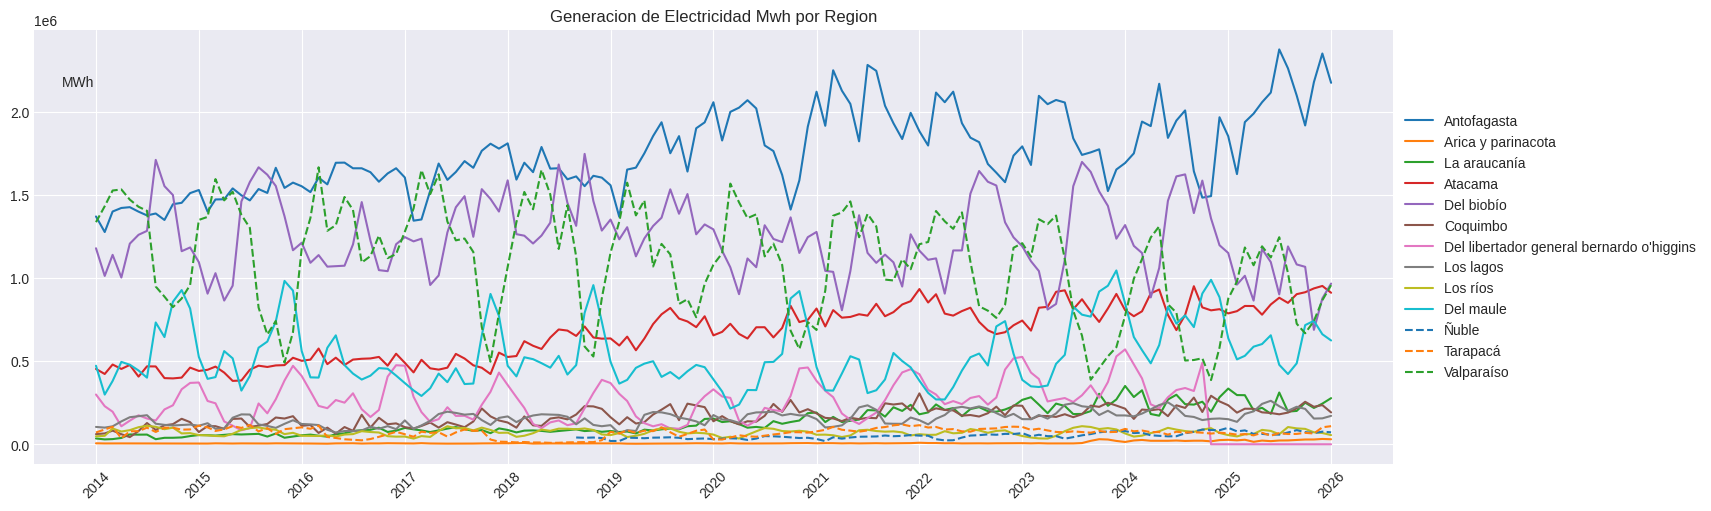

In [384]:
fig, axs = plt.subplots(1, 1, figsize=(17, 5), layout='constrained')
df_electricidad["Date"] = pd.to_datetime(df_electricidad["Date"].astype(str),format="%Y-%d-%m")
j=0
for i in df_electricidad.Región.unique():
  j +=1
  temp = df_electricidad[df_electricidad["Región"] == i ]
  temp = temp.sort_values("Date")

  axs.set_title("MWh", loc='left', y=0.85, x=0.02, fontsize='medium')
  if j >10:
    axs.plot(temp["Date"].values,temp["value"].values,"--",label = i)
  else:
    axs.plot(temp["Date"].values,temp["value"].values,label = i)
  axs.legend(loc='center left', bbox_to_anchor=(1, 0.5))
  axs.set_title("Generacion de Electricidad Mwh por Region")

  #plot por estacion indicando el material particulado por dia, más una linea verde indicando su media

  #formato del ejex para las fechas
  #axs.xaxis.set_major_locator(mdates.MonthLocator(interval = 1))
  axs.xaxis.set_major_locator(mdates.YearLocator())
  axs.xaxis.set_major_formatter( mdates.DateFormatter('%Y'))
  plt.xticks(rotation=45)

Algo interesante de aqui es Valparaiso, se puede apreciar alrededor del 2021 que los peak de electricidad no son tan altos como antes, posiblemente debido al cierre progrsivo de plantas de carbon.

###Principales generadores

In [385]:
df_electricidad.groupby("Región")["value"].sum().sort_values(ascending=False)[:3]

,value
Región,
Antofagasta,2.545870e+08
Del biobío,1.797749e+08
Valparaíso,1.599124e+08


### Distribuidores

In [386]:
df_series_electricidad_dis = siete.buscar(lista_electrcidad[1])

In [387]:
df_electricidad_dis = datos_regionales(ajuste_df_serie(df_series_electricidad_dis))

In [388]:
df_electricidad_dis.drop(columns=["statusCode"],inplace=True)
df_electricidad_dis["Región"] = df_electricidad_dis["Región"].str.split(";",n=1,expand=True)[0].rename("Región")

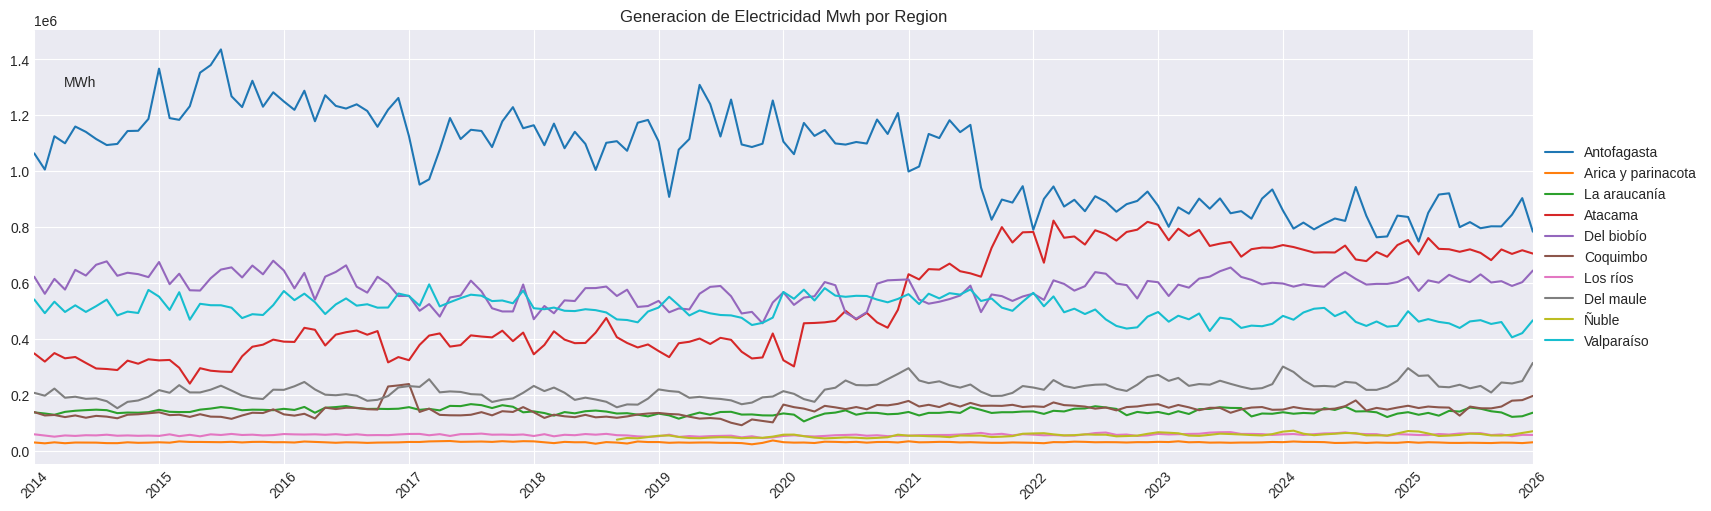

In [389]:
fig, axs = plt.subplots(1, 1, figsize=(17, 5), layout='constrained')
df_electricidad_dis["Date"] = pd.to_datetime(df_electricidad_dis["Date"].astype(str),format="%Y-%d-%m")
for i in df_electricidad_dis.Región.unique():
  temp = df_electricidad_dis[df_electricidad_dis["Región"] == i ]
  temp = temp.sort_values("Date")

  axs.set_title("MWh", loc='left', y=0.85, x=0.02, fontsize='medium')
  axs.plot(temp["Date"],temp["value"],label = i)
  axs.legend(loc='center left', bbox_to_anchor=(1, 0.5))
  axs.set_title("Generacion de Electricidad Mwh por Region")

  #plot por estacion indicando el material particulado por dia, más una linea verde indicando su media

  #formato del ejex para las fechas
  #axs.xaxis.set_major_locator(mdates.MonthLocator(interval = 12))
  axs.xaxis.set_major_locator(mdates.YearLocator())
  axs.xaxis.set_major_formatter( mdates.DateFormatter('%Y'))

  axs.set_xlim(df_electricidad_dis["Date"].min(),
             df_electricidad_dis["Date"].max())
  plt.xticks(rotation=45)

### principales distribuidores

In [390]:
df_electricidad_dis.groupby("Región")["value"].sum().sort_values(ascending=False)[:3]

,value
Región,
Antofagasta,151611160.0
Del biobío,84337717.0
Atacama,76070131.0


### Analisis con el PIB

Buscaremos si existe correlacion entre el pib y el pearson, ademas averiguaremos si el pib esta relacionado con la generacion de electricidad del año pasado.
* primero veremos si se distribuyen normal para decidir si se procede hacer pearson o spearman

In [391]:
def correlacion_con_lag(serie_x, serie_y, lag=1, method='pearson'):
    """
    Correlaciona serie_x rezagada con serie_y
    lag=1: ¿el valor del año anterior de X se relaciona con Y hoy?
    """
    x_lag = serie_x.shift(lag).dropna()

    # Find common index between the shifted x and y to ensure perfect alignment
    common_index = x_lag.index.intersection(serie_y.index)

    # If there are no common dates after shifting, return NaN for correlation and pvalue
    if len(common_index) == 0:
        return float('nan'), float('nan')

    x_lag_aligned = x_lag.loc[common_index]
    y_alineado = serie_y.loc[common_index]

    if method == 'pearson':
        corr, pvalue = pearsonr(x_lag_aligned, y_alineado)
    elif method == 'spearman':
        corr, pvalue = spearmanr(x_lag_aligned, y_alineado)
    else:
        raise ValueError("Method must be 'pearson' or 'spearman'")
    return corr, pvalue

#### Normalidad

In [392]:
print("H0: Los datos siguen una distribución normal")
print("Las as siguientes regiones no se rechazan H0:")

regiones_distrib_norm =[]
regiones_no_distrib_norm =[]
for i in df_quartely[df_quartely.Titulo == "PIB"].Región.unique():
  shap = shapiro(df_quartely[(df_quartely["Región"]== i ) & (df_quartely["Titulo"]=="PIB")].value.values)
  regiones_distrib_norm.append(i) if shap[1] > 0.05 else regiones_no_distrib_norm.append(i)
  if shap[1] > 0.05:
    print(f"Región {i} | shapiro: {shap[0]} | pvalue: {shap[1]}")
  else:
    continue

H0: Los datos siguen una distribución normal
Las as siguientes regiones no se rechazan H0:
Región Tarapacá | shapiro: 0.9711978568499591 | pvalue: 0.2478523414374869
Región Antofagasta | shapiro: 0.9682349858504256 | pvalue: 0.1866455811815218
Región Coquimbo | shapiro: 0.9614113381067995 | pvalue: 0.09580945542567205
Región Del libertador general bernardo ohiggins | shapiro: 0.9596367797074515 | pvalue: 0.08048734829583858
Región Del maule | shapiro: 0.9876029671930715 | pvalue: 0.8683503624892559
Región Del biobío | shapiro: 0.962678129211267 | pvalue: 0.10850148373075202
Región La araucanía | shapiro: 0.9725820160551699 | pvalue: 0.2822712353694885
Región Los lagos | shapiro: 0.9628117921602293 | pvalue: 0.10993452876886795
Región Aysén del general carlos ibáñez del campo | shapiro: 0.9566263096927083 | pvalue: 0.059926747750466504
Región Magallanes y la antártica chilena | shapiro: 0.9871590447724525 | pvalue: 0.8516434870682859
Región Metropolitana santiago | shapiro: 0.9795690986

In [393]:
df_electricidad_2024 = df_electricidad.copy()

In [394]:
df_pib = df_quartely[df_quartely["Titulo"] == "PIB"]
df_pib = df_pib[~df_pib["Región"].isin(['Aysén del general carlos ibáñez del campo','Magallanes y la antártica chilena','Metropolitana santiago'])]
df_electricidad_2024["Región"] = df_electricidad_2024["Región"].str.replace( "Del libertador general bernardo o'higgins",  'Del libertador general bernardo ohiggins', regex=False)
df_pib["Región"] = df_pib["Región"].str.replace( "Del ñuble",  'Ñuble', regex=False)

In [395]:
df_electrico_mean = df_electricidad_2024.groupby(['Región', df_electricidad_2024['Date'].dt.year])['value'].mean().reset_index()

#### Correlacion electricidad y pib

In [396]:
def normalize_quarter_dates(date_series):
    normalized_dates = []
    for dt in date_series:
        year = dt.year
        day = dt.day
        if day == 1: # Q1 (Jan 1)
            normalized_dates.append(pd.Timestamp(year=year, month=1, day=1))
        elif day == 4: # Q2 (Apr 1)
            normalized_dates.append(pd.Timestamp(year=year, month=4, day=1))
        elif day == 7: # Q3 (Jul 1)
            normalized_dates.append(pd.Timestamp(year=year, month=7, day=1))
        elif day == 10: # Q4 (Oct 1)
            normalized_dates.append(pd.Timestamp(year=year, month=10, day=1))
        else:
            normalized_dates.append(dt)
    return pd.Series(normalized_dates, index=date_series.index)

# First, create a quarterly aggregated electricity dataframe
df_electricidad_quarterly = df_electricidad.copy()
# Ensure 'Date' column is datetime and set as index before resampling
df_electricidad_quarterly['Date'] = pd.to_datetime(df_electricidad_quarterly['Date'])
df_electricidad_quarterly = df_electricidad_quarterly.set_index('Date')

# Resample to quarterly frequency (sum of monthly values within each quarter)
df_electricidad_quarterly_agg = df_electricidad_quarterly.groupby('Región')['value'].resample('QS-JAN').sum().reset_index()

df_corre = pd.DataFrame()

for i in df_pib["Región"].unique():
  temp_pib = df_pib[df_pib.Región == i].copy() # Ensure working on a copy
  temp_elec = df_electricidad_quarterly_agg[df_electricidad_quarterly_agg.Región == i].copy() # Ensure working on a copy

  # Normalize PIB dates to standard quarter start dates for alignment
  temp_pib['Date'] = normalize_quarter_dates(temp_pib['Date'])

  # Filter by year for both dataframes to ensure consistent periods
  if i == "Ñuble":
    temp_pib = temp_pib[temp_pib["Date"].dt.year >= 2017]
    temp_elec = temp_elec[temp_elec["Date"].dt.year >= 2017]
  else:
    temp_pib = temp_pib[temp_pib["Date"].dt.year >= 2013]
    temp_elec = temp_elec[temp_elec["Date"].dt.year >= 2013]

  # Align the dates for both PIB and Electricity
  common_start_date = max(temp_pib['Date'].min(), temp_elec['Date'].min())
  common_end_date = min(temp_pib['Date'].max(), temp_elec['Date'].max())

  # Filter both dataframes to this common date range
  temp_pib = temp_pib[(temp_pib['Date'] >= common_start_date) & (temp_pib['Date'] <= common_end_date)]
  temp_elec = temp_elec[(temp_elec['Date'] >= common_start_date) & (temp_elec['Date'] <= common_end_date)]

  # Set 'Date' as index for both series before passing to correlation function
  serie_pib_indexed = temp_pib.set_index('Date')['value']
  serie_elec_indexed = temp_elec.set_index('Date')['value']

  # Determine correlation method
  if i in regiones_no_distrib_norm:
      correlation_method = 'spearman'
  else:
      correlation_method = 'pearson'

  # Correlacion contemporanea
  corr_contem, pvalue_contem = correlacion_con_lag(serie_pib_indexed, serie_elec_indexed, lag=0, method=correlation_method)

  # Correlacion con lag (Elec -> PIB)
  corr_lag, pvalue_lag = correlacion_con_lag(serie_elec_indexed, serie_pib_indexed, lag=1, method=correlation_method)

  # Correlacion con lag (PIB -> Elec)
  corr_lag_pe, pvalue_lag_pe = correlacion_con_lag(serie_pib_indexed, serie_elec_indexed, lag=1, method=correlation_method)

  df_temp = pd.DataFrame({"Contemporaneo":[corr_contem],"p_1>0.05":[pvalue_contem > 0.05],"Lag: Elec -> PIB":[corr_lag],"p_2>0.05":[pvalue_lag > 0.05],"Lag: PIB -> Elec":[corr_lag_pe],"p_3>0.05":[pvalue_lag_pe > 0.05], "correlacion":correlation_method },index =[i])

  df_corre = pd.concat([df_corre,df_temp])
df_corre.index = df_pib.Región.unique() # This line ensures the final index is correctly set with region names

Ahora que tenemos la correlacion, seria interesante estudiar si la generacion y el pib crecen contemporaneamente (crecen juntos y al mismo tiempo), tambien si la generacion de electricidad o el pib del año anterior causa un crecimiento en alguno de ellos. Tambien como dato adicional se añadira la columna del principal servicio de la region.

In [397]:
df_temp = df_tres_serv_per_region.Servicio_1.reset_index()
df_temp = df_temp[~df_temp["Región"].isin(['Aysén del general carlos ibáñez del campo','Magallanes y la antártica chilena','Metropolitana santiago'])]
df_temp["Región"] = df_temp["Región"].str.replace( "Del ñuble",  'Ñuble', regex=False)
df_temp.set_index("Región",inplace=True)

df_corre["Principal PIB"] = df_temp

df_corre

,Contemporaneo,p_1>0.05,Lag: Elec -> PIB,p_2>0.05,Lag: PIB -> Elec,p_3>0.05,correlacion,Principal PIB
Tarapacá,0.158913,True,0.221083,True,0.237906,True,pearson,PIB Minería
Antofagasta,0.095690,True,0.150088,True,0.037229,True,pearson,PIB Minería
Atacama,0.564177,False,0.564231,False,0.487758,False,spearman,PIB Minería
Coquimbo,0.745175,False,0.763934,False,0.580600,False,pearson,PIB Minería
Valparaíso,-0.392345,False,-0.448905,False,-0.153623,True,spearman,PIB Servicios personales
Del libertador general bernardo ohiggins,NaN,False,NaN,False,NaN,False,pearson,PIB Agropecuario-silvícola
Del maule,0.300796,False,0.391868,False,-0.255108,True,pearson,PIB Agropecuario-silvícola
Del biobío,-0.051059,True,0.089294,True,0.029567,True,pearson,PIB Industria manufacturera
La araucanía,0.887654,False,0.851367,False,0.806181,False,pearson,PIB Servicios personales
Los lagos,0.598275,False,0.558574,False,0.618189,False,pearson,PIB Servicios personales


Rechazamos las filas y columnas donde el pvlue es True. Lo interesante se encuentra en el norte (Araucania, Ñuble, Coquimbo y Atacama ) donde un el PIB tiene un mayor impacto cuando crece la generacion de electricidad del año anterior en la region, esto posiblemente debido al rubro minero. Mientras que algunas regiones (Los lagos y Arica y parinacota) con principal rubro los Servicios personales (Actividades deportivas, artisticas, de entretencion, peluquerias,etc...) arrastran la demanda energetica.

####Comparacion de tendencias

In [398]:
def comparativa_tendencia(df_1,df_2):
  x_norm =  (df_1["value"] - df_1["value"].mean())/df_1["value"].std()
  pendiente_1 = tendencia(x_norm)
  y_norm = (df_2["value"] - df_2["value"].mean())/df_2["value"].std()
  pendiente_2 = tendencia(y_norm)
  diff = pendiente_1 - pendiente_2
  return diff

In [399]:
print("La generacion de electricidad y el pib normalizado:")
print(" ")
for i in df_pib["Región"].unique():
  temp_pib = df_pib[df_pib.Región == i]
  temp_elec = df_electrico_mean[df_electrico_mean.Región == i]

  if i =="Ñuble":
    temp_pib = temp_pib[temp_pib["Date"] >"01-01-2017" ]
  else:
    temp_pib = temp_pib[temp_pib["Date"] >"01-01-2013" ]

  temp_elec = temp_elec[temp_elec["Date"] <2025 ]

  diff = comparativa_tendencia(temp_pib, temp_elec).round(4)
  if diff>-0.2 and diff<0.2:
    print(f"En {i}, tienen un valor de {diff}", ", Crecen juntos")
  elif diff >0.2:
    print(f"En {i}, tienen un valor de {diff}", ", El PIB crece mas rapido")
  else:
    print(f"En {i}, tienen un valor de {diff}", ", Genera cada vez mas electricidad, pero no se refleja en el PIB")

La generacion de electricidad y el pib normalizado:
 
En Tarapacá, tienen un valor de 0.0139 , Crecen juntos
En Antofagasta, tienen un valor de -0.2303 , Genera cada vez mas electricidad, pero no se refleja en el PIB
En Atacama, tienen un valor de -0.249 , Genera cada vez mas electricidad, pero no se refleja en el PIB
En Coquimbo, tienen un valor de -0.2312 , Genera cada vez mas electricidad, pero no se refleja en el PIB
En Valparaíso, tienen un valor de 0.2846 , El PIB crece mas rapido
En Del libertador general bernardo ohiggins, tienen un valor de -0.1701 , Crecen juntos
En Del maule, tienen un valor de -0.035 , Crecen juntos
En Del biobío, tienen un valor de 0.057 , Crecen juntos
En La araucanía, tienen un valor de -0.23 , Genera cada vez mas electricidad, pero no se refleja en el PIB
En Los lagos, tienen un valor de -0.191 , Crecen juntos
En Los ríos, tienen un valor de 0.084 , Crecen juntos
En Arica y parinacota, tienen un valor de -0.1568 , Crecen juntos
En Ñuble, tienen un valor

En todas las ciudades tienen un valor positivo en la generacion del pib y electricidad.

## Serie de tiempo

**¿Es posible predecir el PIB regional usando la generación eléctrica como variable anticipadora?**

```
# Esto tiene formato de código
```



En esta seccion vamos a experimentar un poco, se tratara de predecir el pib futuro usando la prediccion de la serie de tiempo de la generacion electrica.

El plan seria:
1. Entrenar dataset mensuale con ARIMA y SARIMA (más robusto)
2. Usar los datos de validacion y estudiar el error
3. Obtener los promedios mensuales de los datos de prediccion
4. Regresion: PIB = m Elec + b
5. Si todo sale con los datos de validacion del PIB; calcular el error de todo junto.

In [400]:
df_electricidad_train = df_electricidad[df_electricidad["Date"].dt.year < 2023]
df_electricidad_val = df_electricidad[df_electricidad["Date"].dt.year >= 2023]

In [401]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

Primero revisaremos si pasa el test de Dickey-Fuller aumentado que mide si una serie es estacionaria o no, los criterios serian que el test sea suficientemente negativa para que el pvalue sea menor a 5%.

Reviso cada region:

In [402]:
for i in df_electricidad_train.Región.unique():
  result = adfuller(df_electricidad_train[df_electricidad_train["Región"] == i].value)
  if result[0]<0 and result[1]<0.05:
    print(i,":")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(" ")

Arica y parinacota :
ADF Statistic: -3.6699179372427846
p-value: 0.0045567422848927
 
Los lagos :
ADF Statistic: -4.299523628683564
p-value: 0.0004450568700012955
 
Los ríos :
ADF Statistic: -3.0380995884414994
p-value: 0.03148633729877245
 
Del maule :
ADF Statistic: -4.62188228113752
p-value: 0.00011769070800080546
 
Tarapacá :
ADF Statistic: -3.274184678847669
p-value: 0.016072601095143847
 


Este test nos indica si para cierta region es sufientemente estacionario los datos para el uso del modelo ARIMA. Curiosamente algunos son regiones que necesitan PIB para generar electricidad el siguiente año, por lo que, no resulta buena idea hacerlo.
Ahora bien los datos de electricidad son mensuales, es decir tienen picos en ciertos meses del año, podemos experimentar haciendo diff de 1 y 2 meses (nos quita 1 o 2 datos).

In [403]:
#Lag(6)
for i in df_electricidad_train.Región.unique():
  data = df_electricidad_train[df_electricidad_train["Región"] == i].value.diff(1)
  data = data.dropna()
  result = adfuller(data)
  if result[0]<0 and result[1]<0.05:
    print(i,":")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(" ")

Antofagasta :
ADF Statistic: -3.4342243039637745
p-value: 0.009846047368329731
 
Arica y parinacota :
ADF Statistic: -6.00667479905359
p-value: 1.609355846038301e-07
 
La araucanía :
ADF Statistic: -6.5926755728684805
p-value: 7.050232890748414e-09
 
Atacama :
ADF Statistic: -3.4253930069369742
p-value: 0.010123090469464316
 
Del biobío :
ADF Statistic: -7.421925803590967
p-value: 6.701291386225955e-11
 
Coquimbo :
ADF Statistic: -7.697181193469151
p-value: 1.3694224103746639e-11
 
Del libertador general bernardo o'higgins :
ADF Statistic: -10.394575840823842
p-value: 1.9805126370478136e-18
 
Los lagos :
ADF Statistic: -6.047646311257381
p-value: 1.3002364786126545e-07
 
Los ríos :
ADF Statistic: -6.825876052360847
p-value: 1.9485712565029917e-09
 
Del maule :
ADF Statistic: -7.169389466840928
p-value: 2.8304870530852786e-10
 
Ñuble :
ADF Statistic: -6.93237199484018
p-value: 1.0759082232724599e-09
 
Tarapacá :
ADF Statistic: -8.246262898631944
p-value: 5.543565004647456e-13
 
Valparaí

In [404]:
#lag(12)
for i in df_electricidad_train.Región.unique():
  data = df_electricidad_train[df_electricidad_train["Región"] == i].value.diff(2)
  data = data.dropna()
  result = adfuller(data)
  if result[0]<0 and result[1]<0.05:
    print(i,":")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(" ")

Antofagasta :
ADF Statistic: -3.417056251857439
p-value: 0.010390986581865535
 
Arica y parinacota :
ADF Statistic: -5.790041432610056
p-value: 4.896436456499948e-07
 
La araucanía :
ADF Statistic: -2.9219580585694125
p-value: 0.04285351112464904
 
Atacama :
ADF Statistic: -3.363337387013084
p-value: 0.012274027451344087
 
Coquimbo :
ADF Statistic: -8.075078187236912
p-value: 1.5131185022240298e-12
 
Del libertador general bernardo o'higgins :
ADF Statistic: -3.1797379887009454
p-value: 0.021187891325274478
 
Los lagos :
ADF Statistic: -3.9303581270968664
p-value: 0.001822446737902534
 
Los ríos :
ADF Statistic: -7.3736831896439865
p-value: 8.835880842486064e-11
 
Del maule :
ADF Statistic: -3.8669651677894428
p-value: 0.002291874011425711
 
Ñuble :
ADF Statistic: -4.029861022676767
p-value: 0.0012619736749583154
 
Tarapacá :
ADF Statistic: -4.4393229379926415
p-value: 0.0002527145346681177
 
Valparaíso :
ADF Statistic: -4.311635610458977
p-value: 0.0004240483172808004
 


lag de 6 meses fue superior, haciendo que las regiones que si dependen de la generacion electrica (antofagasta y atacama) para el aumento del pib pase el test de estacionalidad. Por lo que, se puede usar ARIMA y SARIMA (modelo parecido a arima pero que considera periodos o ciclos de tiempo, como la generacion de electricidad (invierno mas, verano menos)).

verifiquemos la estacionalidad, en los siguientes graficos deberia haber una caida rapida en los primeros datos de lags.

In [405]:
regiones = ["Antofagasta","Atacama","La araucanía"]# Regiones participantes, considerando esta vez la araucania


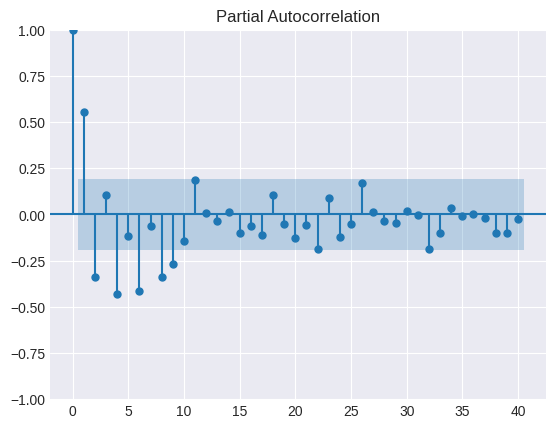

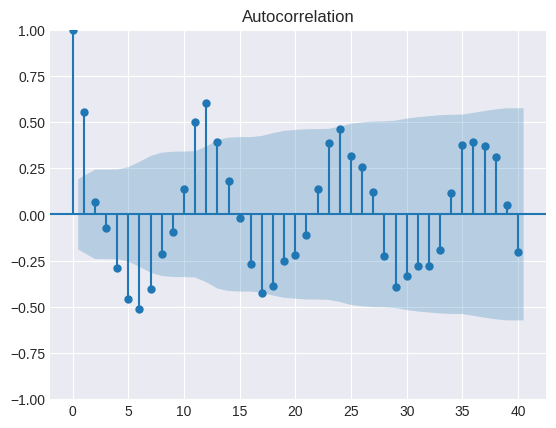

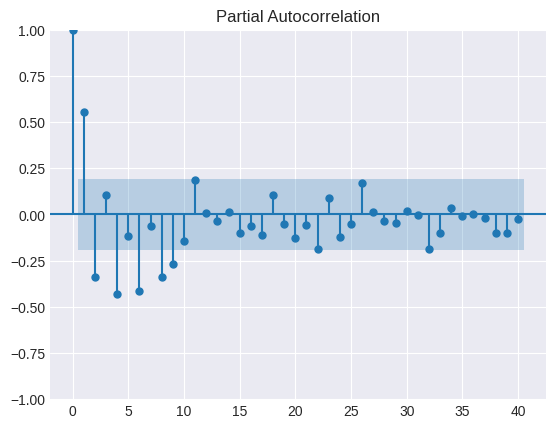

In [406]:
data_train = df_electricidad_train[df_electricidad_train["Región"] == regiones[0]].value.diff(1)
data_train = data.dropna()
plot_acf(data_train, lags=40)
plot_pacf(data_train, lags=40)

Caida fuerte en AFC Y PAFC con diff 1, no hay estructura de definida para ar y ma.

---
Construccion de modelos ARIMA Y SARIMA

###Clases de modelos

#### model arima

In [407]:
class modelo_ARIMA:
    def __init__(self, data,corte,region, scaling_log =False):
      self.data = data[data["Región"] == region]

      if scaling_log ==True:
        self.data.value = np.log(self.data.value)

      data_train = self.data[self.data["Date"].dt.year < corte]
      data_train = data_train.set_index('Date')
      data_train = data_train.asfreq('MS')

      data_test = self.data[self.data["Date"].dt.year >= corte]
      data_test = data_test.set_index('Date')
      data_test = data_test.asfreq('MS')

      self.train = data_train.value
      self.test = data_test.value

      self.model_fit = None
      self.forecast = None
      self.rmse = None

    def fit(self, order):
      model = ARIMA(self.train, order=order)
      self.model_fit = model.fit()


    def predict(self):
      self.forecast = self.model_fit.forecast(steps=len(self.test))
      return self.forecast

    def evaluate(self,imprimir=True):
        from sklearn.metrics import mean_squared_error
        import numpy as np
        # Mientras mas bajo se ajusta mejor
        if imprimir == True:
          print(f"AIC: {self.model_fit.aic}")
          print(f"BIC: {self.model_fit.bic}")

        self.rmse = np.sqrt(mean_squared_error(self.test, self.forecast))
        return self.rmse

    def model_summary(self):
      return self.model_fit.summary()

    def residual(self):
      # plot residual errors
      residuals = model_fit.resid
      residuals.hist(bins=30)
      plt.show()

    def plot(self):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(self.train.index, self.train, label='Train', color='blue')
        plt.plot(self.test.index, self.test, label='Test', color='green')
        plt.plot(self.test.index, self.forecast, label='Forecast', color='red')

        plt.legend()
        plt.title('ARIMA Forecast vs Actual')
        plt.show()


    def buscar_parametros(self, orders):
        best_score = float("inf")
        best_params = None

        for order in orders:
              try:
                  self.fit(order)
                  self.predict()
                  rmse = self.evaluate(imprimir = False)

                  if rmse < best_score:
                      best_score = rmse
                      best_params = (order)

              except:
                  continue

        return best_params, best_score

    def export_data(self):
      return self.train, self.test

####model SARIMA


In [408]:
class modelo_SARIMA:
    def __init__(self, data,corte,region,scaling_log = False):
      self.data = data[data["Región"] == region]

      if scaling_log ==True:
        self.data.value = np.log(self.data.value)

      data_train = self.data[self.data["Date"].dt.year < corte]
      data_train = data_train.set_index('Date')
      data_train = data_train.asfreq('MS')

      data_test = self.data[self.data["Date"].dt.year >= corte]
      data_test = data_test.set_index('Date')
      data_test = data_test.asfreq('MS')

      self.train = data_train.value
      self.test = data_test.value

      self.model_fit = None
      self.forecast = None
      self.rmse = None

    def fit(self, order, seasonal_order):
      model = SARIMAX(self.train, order=order, seasonal_order=seasonal_order,enforce_stationarity=False,
                                                                            enforce_invertibility=False)
      self.model_fit = model.fit(method='lbfgs')

    def predict(self):
        self.forecast = self.model_fit.forecast(steps=len(self.test))
        return self.forecast

    def evaluate(self,imprimir=True):
        from sklearn.metrics import mean_squared_error
        import numpy as np
        # Mientras mas bajo se ajusta mejor
        if imprimir == True:
          print(f"AIC: {self.model_fit.aic}")
          print(f"BIC: {self.model_fit.bic}")

        self.rmse = np.sqrt(mean_squared_error(self.test, self.forecast))
        return self.rmse

    def residual(self,plotear = True):
      # plot residual errors
      residuals = self.model_fit.resid
      if plotear == True:
        residuals.hist(bins=30)
        plt.show()
      return residuals

    def plot(self):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(self.train.index, self.train, label='Train', color='blue')
        plt.plot(self.test.index, self.test, label='Test', color='green')
        plt.plot(self.test.index, self.forecast, label='Forecast', color='red')

        plt.legend()
        plt.title('SARIMA Forecast vs Actual')
        plt.show()


    def buscar_parametros(self, orders, seasonal_orders):
        best_score = float("inf")
        best_rmse = float("inf")
        best_params = None

        for order in orders:
            for s_order in seasonal_orders:
                try:
                    print(1)
                    self.fit(order, s_order)
                    self.predict()
                    rmse = self.evaluate(imprimir = False)
                    res = self.residual(plotear=False)
                    print(2)
                    if self.model_fit.aic < best_score:
                      best_score = self.model_fit.aic
                      print("aic")
                      # H0: The residuals are independently distributed.
                      lb = sm.stats.acorr_ljungbox(res, lags=[5], return_df=True) # test Ljung-Box para determinar la normalidad de los residuos
                      if (lb["lb_pvalue"] > 0.05).mean() == np.False_:
                        print("lb")
                        if rmse < best_rmse:
                          print("rmse")
                          best_rmse = rmse
                          best_params = (order, s_order)

                except:
                    continue

        return best_params, best_score

    def export_data(self):
      return self.train, self.test

###ARIMA

/tmp/ipykernel_4994/2713931081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


AIC: -241.48013333850557
BIC: -233.48981605616936
RMSE: 0.1308278400257584


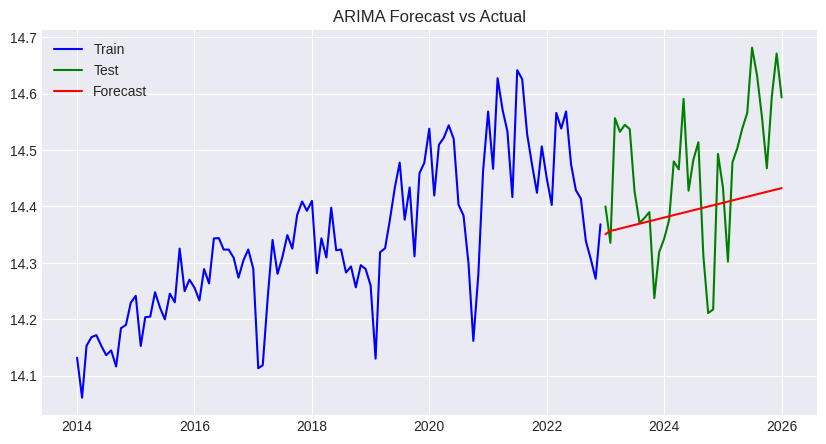

In [409]:
p, d, q = 1, 2, 1
order = (p, d, q)
model = modelo_ARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(order)
modelo_summary = model.model_summary()

modelo_summary
model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

Busquemos los mejores parametros

In [410]:
import itertools as itertools

In [411]:
num_orders = [0,1,2,3] # probamos hasta (3,3,3)
ordes = list(itertools.combinations_with_replacement(num_orders,3))
best_order, error = model.buscar_parametros(ordes)
print(f"mejores parametros:{best_order} con error de {error}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.p

mejores parametros:(1, 2, 2) con error de 0.12060990334404434


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/tmp/ipykernel_4994/2713931081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


AIC: -243.03035151207789
BIC: -232.37659513562963
RMSE: 0.12060990334404434


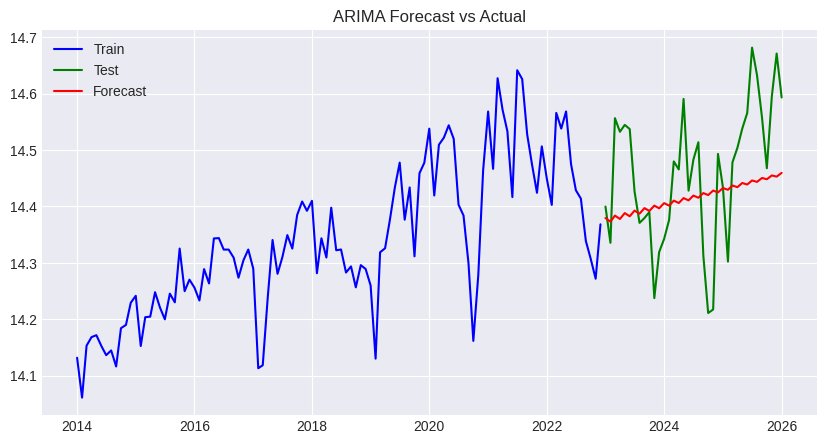

In [412]:

model = modelo_ARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(best_order)
modelo_summary = model.model_summary()

modelo_summary
model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

Probando parametros, no se consigue un modelo interesante.

###SARIMA

/tmp/ipykernel_4994/670926797.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


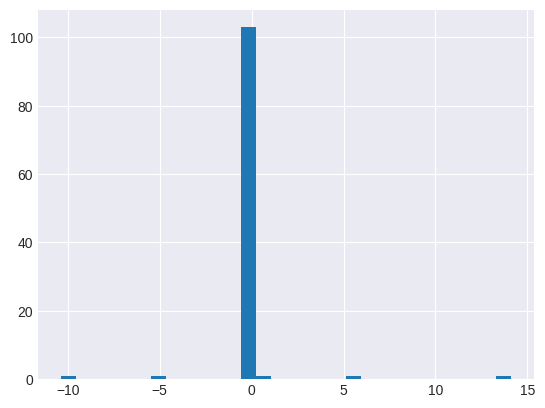

AIC: -187.4621959614466
BIC: -179.89683023029949
RMSE: 0.47184944269297685


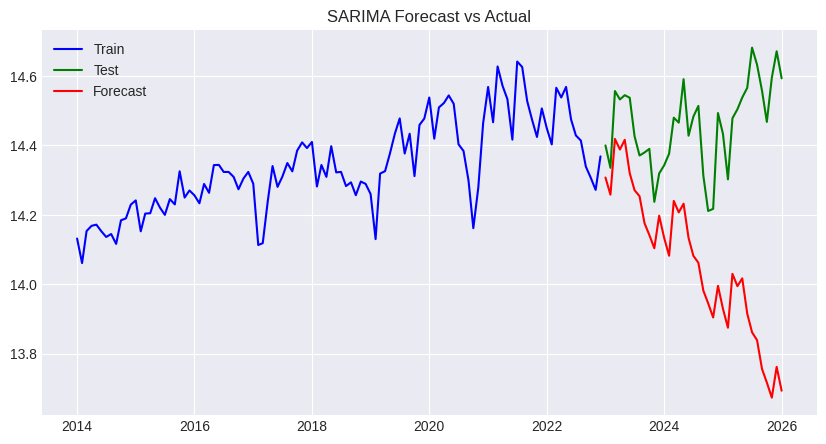

In [413]:
p, d, q = 1, 2, 1
order = (p, d, q)
seasonal_order=(0,1,0,12)
model = modelo_SARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(order,seasonal_order)
residuos = model.residual()
lb = sm.stats.acorr_ljungbox(residuos, lags=range(1,25), return_df=True) # test Ljung-Box para determinar la normalidad de los residuos


model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

Buscamos los mejores parametros

In [414]:
num_orders = [0,1,2]
orders = list(itertools.product(num_orders, repeat=3))
orders = [t for t in orders if t[1] <= 2]

seasonal_base = list(itertools.product([0,1], repeat=3))# evitar  Q >= 2, soluciona error de Non-invertible
seasonal_base = [t for t in seasonal_base if t[1] <= 1]# evitar D=2 # eliminar warning de
seasonal_orders = [t + (12,) for t in seasonal_base]

model = modelo_SARIMA(df_electricidad,2023,regiones[0],scaling_log = True)

best_order, error = model.buscar_parametros(orders,seasonal_orders)
print(f"mejores parametros:{best_order} con error de {error}")

/tmp/ipykernel_4994/670926797.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


1
2
aic
lb
rmse
1
2
aic
lb
rmse
1
2
aic
lb
rmse
1
2
1
2
aic
lb
rmse
1
2
aic
lb
1
2
1
2
1


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2
1
2
1
2
aic
lb
1
2
1
2
aic
lb
rmse
1


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
1
2
mejores parametros:((0, 0, 2), (1, 0, 0, 12)) con error de -252.14890601726438


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/tmp/ipykernel_4994/670926797.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


AIC: -200.8526482184786
BIC: -190.59525545260726
RMSE: 0.10551253658643854


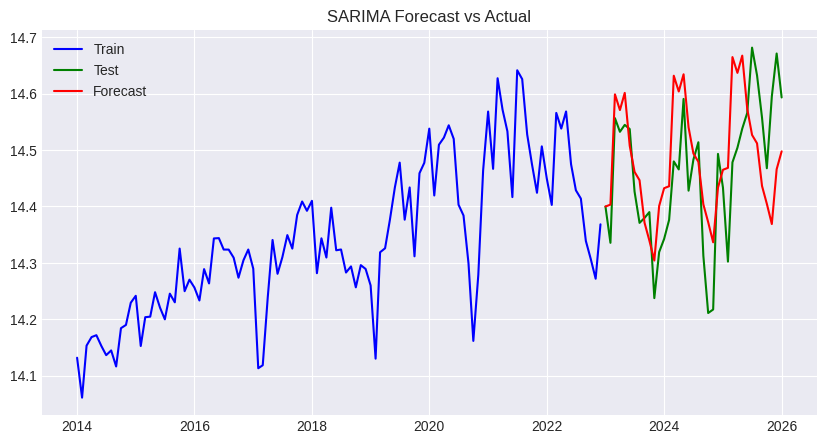

In [415]:
model = modelo_SARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(best_order[0],best_order[1])

model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

##

##Predecir PIB

Esta prediccion es usando los datos contemporaneo, es decir generacion de electricidad 2024 predice el pib del 2024. Seria interesante luego predecir usando lag(1).

In [416]:
data_forescast_test

,value
0,43.401814
1,43.679749
2,43.278986
3,43.044547
4,43.499902
5,43.778465
6,43.376796
7,43.141827
8,43.598212
9,43.877404


In [417]:
data_train, data_test = model.export_data()

data_train = data_train.reset_index()
data_train["Date"] = pd.to_datetime(data_train['Date'])
data_train = data_train.set_index('Date')['value'].resample('QS-JAN').sum().reset_index()
data_train = data_train.reset_index()
data_elec_train = data_train['value']

data_test = data_test.reset_index()
data_test["Date"] = pd.to_datetime(data_test['Date'])
data_test = data_test.set_index('Date')['value'].resample('QS-JAN').sum().reset_index()
data_test = data_test.reset_index()
data_elec_test = data_test['value']


data_forescast = model.predict()
data_forescast = data_forescast.reset_index()
data_forescast = data_forescast.reset_index().rename(columns = {"index":"Date","predicted_mean":"value"})
data_forescast["Date"] = pd.to_datetime(data_forescast['Date'])
data_forescast = data_forescast.set_index('Date')['value'].resample('QS-JAN').sum().reset_index()
data_forescast_test = data_forescast['value']



data_pib = df_pib[df_pib["Región"] == "Antofagasta"]
data_pib_train = data_pib[(data_pib["Date"].dt.year>2013) & (data_pib["Date"].dt.year<2023)]
data_pib_train = data_pib_train.reset_index()
data_pib_test = data_pib[(data_pib["Date"].dt.year>=2023)]


In [418]:
x_lag = data_elec_train.shift(0).dropna()
y_alineado = data_pib_train.loc[x_lag.index]

In [419]:
parametros = linregress(x_lag.values, y_alineado.value)

In [420]:
pib_predict_elec_real = parametros.slope*data_elec_test.values + parametros.intercept
pib_predict_elec_predict = parametros.slope*data_forescast_test.values + parametros.intercept

In [421]:
df_prediccion_pib = pd.DataFrame(columns=["PIB","PIB prediccion elec test","error abs test","error rel test","PIB prediccion elec predict","error abs sarima","error rel sarima"])
df_prediccion_pib["PIB"] = np.concat([data_pib_test.value.values , np.array([None,None])])
df_prediccion_pib["PIB prediccion elec test"] = pib_predict_elec_real
df_prediccion_pib["PIB prediccion elec predict"] = pib_predict_elec_predict

df_prediccion_pib["error abs test"] = np.abs(df_prediccion_pib["PIB"] - df_prediccion_pib["PIB prediccion elec test"])
df_prediccion_pib["error abs sarima"] = np.abs(df_prediccion_pib["PIB"] - df_prediccion_pib["PIB prediccion elec predict"])

df_prediccion_pib["error rel test"] = df_prediccion_pib["error abs test"]/df_prediccion_pib["PIB"]
df_prediccion_pib["error rel sarima"] = df_prediccion_pib["error abs sarima"]/df_prediccion_pib["PIB"]

In [422]:
df_prediccion_pib

,PIB,PIB prediccion elec test,error abs test,error rel test,PIB prediccion elec predict,error abs sarima,error rel sarima
0,3735.137848,3918.399141,183.261293,0.049064,3916.626596,181.488748,0.04859
1,3847.985998,3913.203833,65.217834,0.016949,3912.146151,64.160153,0.016674
2,4223.037283,3920.254730,302.782553,0.071698,3918.606653,304.43063,0.072088
3,4282.388434,3923.968496,358.419938,0.083696,3922.385935,360.002498,0.084066
4,4014.6874,3919.906490,94.78091,0.023609,3915.045369,99.642031,0.024819
5,4085.774373,3915.298228,170.476145,0.041724,3910.554798,175.219575,0.042885
6,4456.431039,3918.118598,538.312441,0.120795,3917.029901,539.401138,0.121039
7,4700.237252,3924.371844,775.865408,0.165069,3920.817724,779.419528,0.165826
8,4154.891438,3919.661248,235.230191,0.056615,3913.460568,241.43087,0.058108
9,4263.261369,3913.305279,349.956089,0.082086,3908.959849,354.301519,0.083106


In [423]:
print(f"El error relativo usando la prediccion del modelo SARIMA es {df_prediccion_pib['error rel sarima'].mean()}")
print(f"El error relativo usando la prediccion del modelo con los datos test es {df_prediccion_pib['error rel test'].mean()}")

El error relativo usando la prediccion del modelo SARIMA es 0.07511683160772963
El error relativo usando la prediccion del modelo con los datos test es 0.07471321992784073


Conclusion: El modelo SARIMA (mejor evaluado) arrojo un peor error, resultado de la propagacion de errores. Si bien el modelo lineal con solo datos del testeo es bastante bueno (7,4%), era bueno experimentar un modelo mas robusto como SARIMA. Esto deja enseñanza de que no solo por que sea un modelo grande significa mejor.

#### Modelo AutoRegresivo

In [424]:
from sklearn.linear_model import LinearRegression

model_auto = LinearRegression()


In [425]:
X = data_elec_train.to_frame().copy()
X["Lag0"] = data_elec_train.to_frame()
X["Lag1"] = data_elec_train.to_frame().shift(1)
X = X.dropna()
x_lag = X[["Lag0","Lag1"]]
y_alineado = data_pib_train.loc[x_lag.index]

In [426]:
model_auto.fit(x_lag.values, y_alineado.value.values)

LinearRegression()

In [427]:
X_forescat = data_forescast_test.to_frame().copy()
X_forescat["lag"]=X_forescat.shift(1)
X_forescat.fillna(data_elec_test[0],inplace=True)

In [428]:
pib_predict_elec_predict

array([3916.62659572, 3912.14615088, 3918.60665314, 3922.38593523,
       3915.04536889, 3910.55479826, 3917.02990122, 3920.81772448,
       3913.46056849, 3908.95984919, 3915.44958586, 3919.24596958,
       4382.57615585])

In [429]:
pib_predict_elec_real = parametros.slope*data_elec_test.values + parametros.intercept
pib_predict_elec_predict = model_auto.coef_[0] *X_forescat.value.values  + model_auto.coef_[1] * X_forescat["lag"].values + parametros.intercept

In [430]:
df_prediccion_pib = pd.DataFrame(columns=["PIB","PIB prediccion elec forescast","error abs sarima","error rel sarima"])
df_prediccion_pib["PIB"] = np.concat([data_pib_test.value.values , np.array([None,None])])
df_prediccion_pib["PIB prediccion elec forescast"] = pib_predict_elec_predict
df_prediccion_pib["error abs sarima"] = np.abs(df_prediccion_pib["PIB"] - df_prediccion_pib["PIB prediccion elec forescast"])
df_prediccion_pib["error rel sarima"] = df_prediccion_pib["error abs sarima"]/df_prediccion_pib["PIB"]

In [431]:
df_prediccion_pib

,PIB,PIB prediccion elec forescast,error abs sarima,error rel sarima
0,3735.137848,2288.171098,1446.96675,0.387393
1,3847.985998,2283.848690,1564.137308,0.406482
2,4223.037283,2262.457663,1960.57962,0.464258
3,4282.388434,2285.596893,1996.791541,0.46628
4,4014.6874,2304.753097,1709.934303,0.42592
5,4085.774373,2278.577392,1807.196981,0.442314
6,4456.431039,2257.138021,2199.293018,0.49351
7,4700.237252,2280.329546,2419.907707,0.514848
8,4154.891438,2299.529042,1855.362396,0.446549
9,4263.261369,2273.294181,1989.967188,0.466771


Por ahora un autoregresion da mayor error.

**Para mejorar esto se esperara tener mas datos del pib, talvez trimestrales**

# Visualización

In [432]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configure a consistent style for plots
plt.style.use('seaborn-v0_8-darkgrid')

def grafico_evolucion_pib(df, region):
    """
    Genera un gráfico de líneas que muestra la evolución del PIB por sector
    a lo largo del tiempo para una región específica.

    Args:
        df (pd.DataFrame): DataFrame con los datos de PIB por sector y región.
                           Debe contener las columnas 'Date', 'Región', 'Titulo' y 'value'.
        region (str): Nombre de la región a visualizar.
    """
    df_region = df[df['Región'] == region]

    fig = plt.figure(figsize=(15, 8))
    sns.lineplot(data=df_region, x='Date', y='value', hue='Titulo', marker='o')
    plt.title(f'Evolución del PIB por Sector en la Región de {region}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Valor del PIB (miles de millones de pesos)', fontsize=12)
    plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig

def heatmap_correlacion(df, region):
    """
    Genera un heatmap de correlación entre los sectores de una región específica.

    Args:
        df (pd.DataFrame): DataFrame con los datos de PIB por sector y región.
                           Debe contener las columnas 'Date', 'Región', 'Titulo' y 'value'.
        region (str): Nombre de la región a visualizar.
    """
    df_region = df[df['Región'] == region]

    # Pivotear la tabla para tener los sectores como columnas y las fechas como índice
    df_pivot = df_region.pivot_table(index='Date', columns='Titulo', values='value')

    # Calcular la matriz de correlación
    correlation_matrix = df_pivot.corr()

    fig = plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'Matriz de Correlación entre Sectores en la Región de {region}', fontsize=16)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    return fig


### Evolución del PIB por Sector (Ejemplo: Región de Antofagasta)

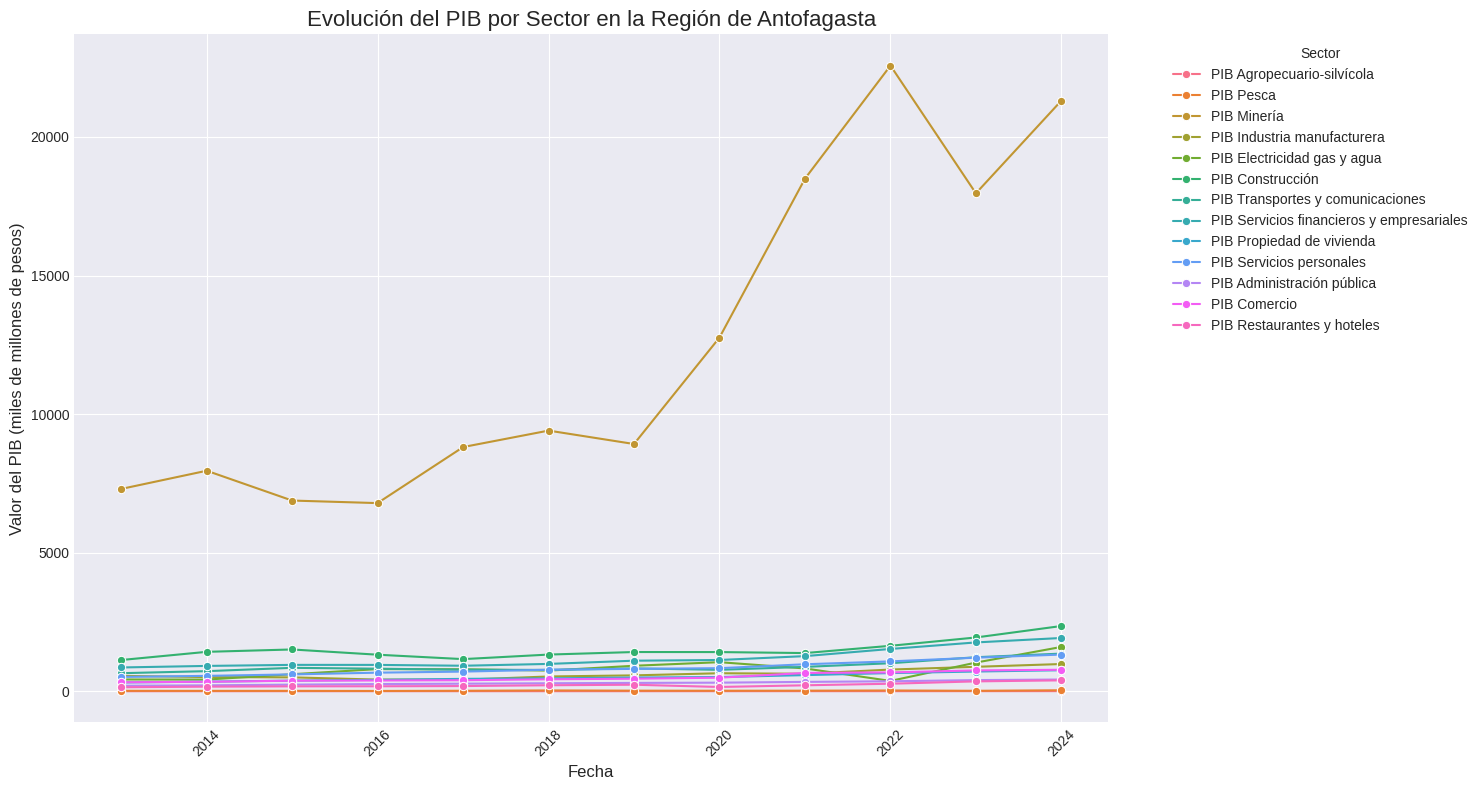

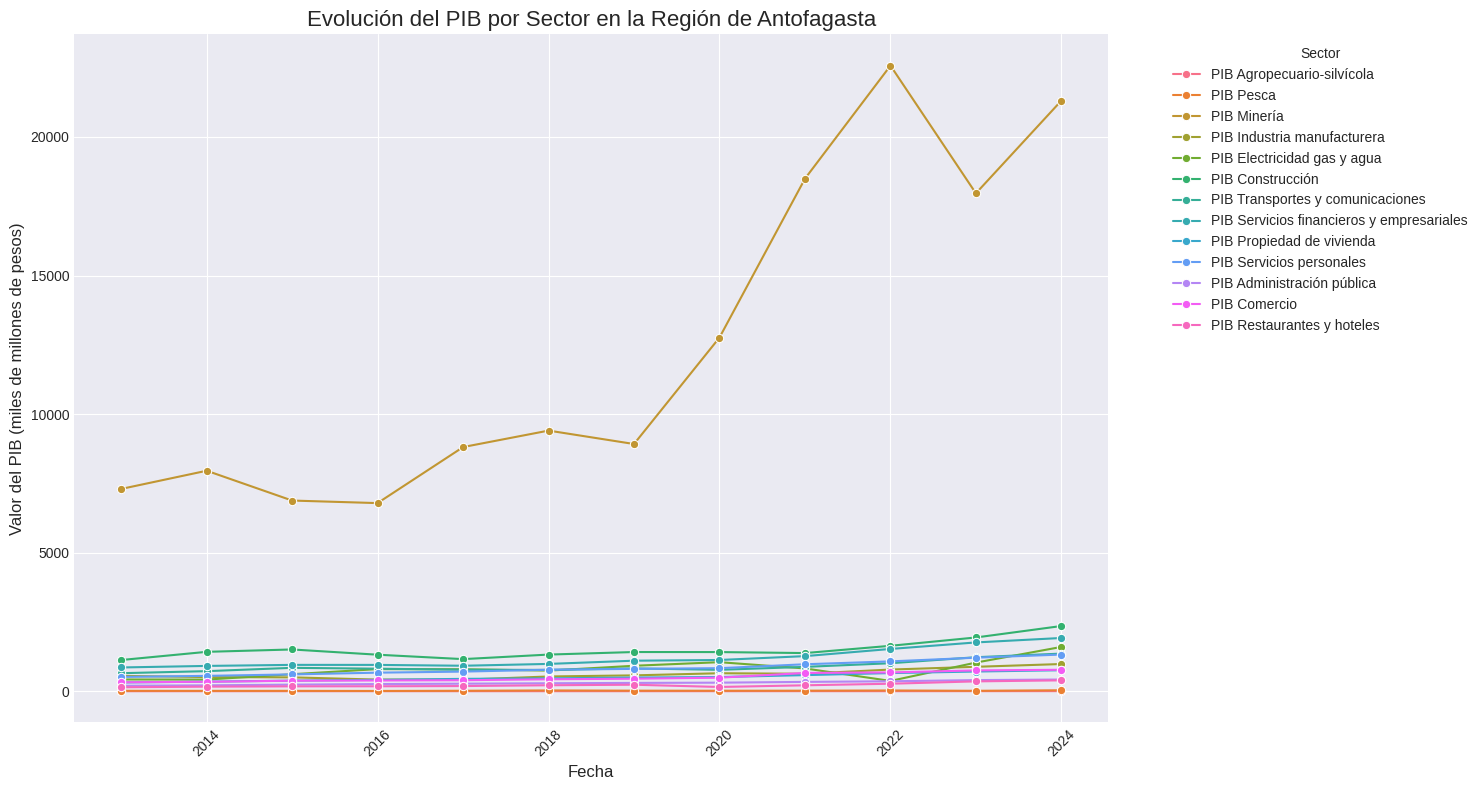

In [433]:
# Usando el dataframe 'df_final_servicios' que contiene los datos de PIB por sector y región
grafico_evolucion_pib(df_final_servicios, 'Antofagasta')

### Heatmap de Correlación entre Sectores (Ejemplo: Región de Antofagasta)

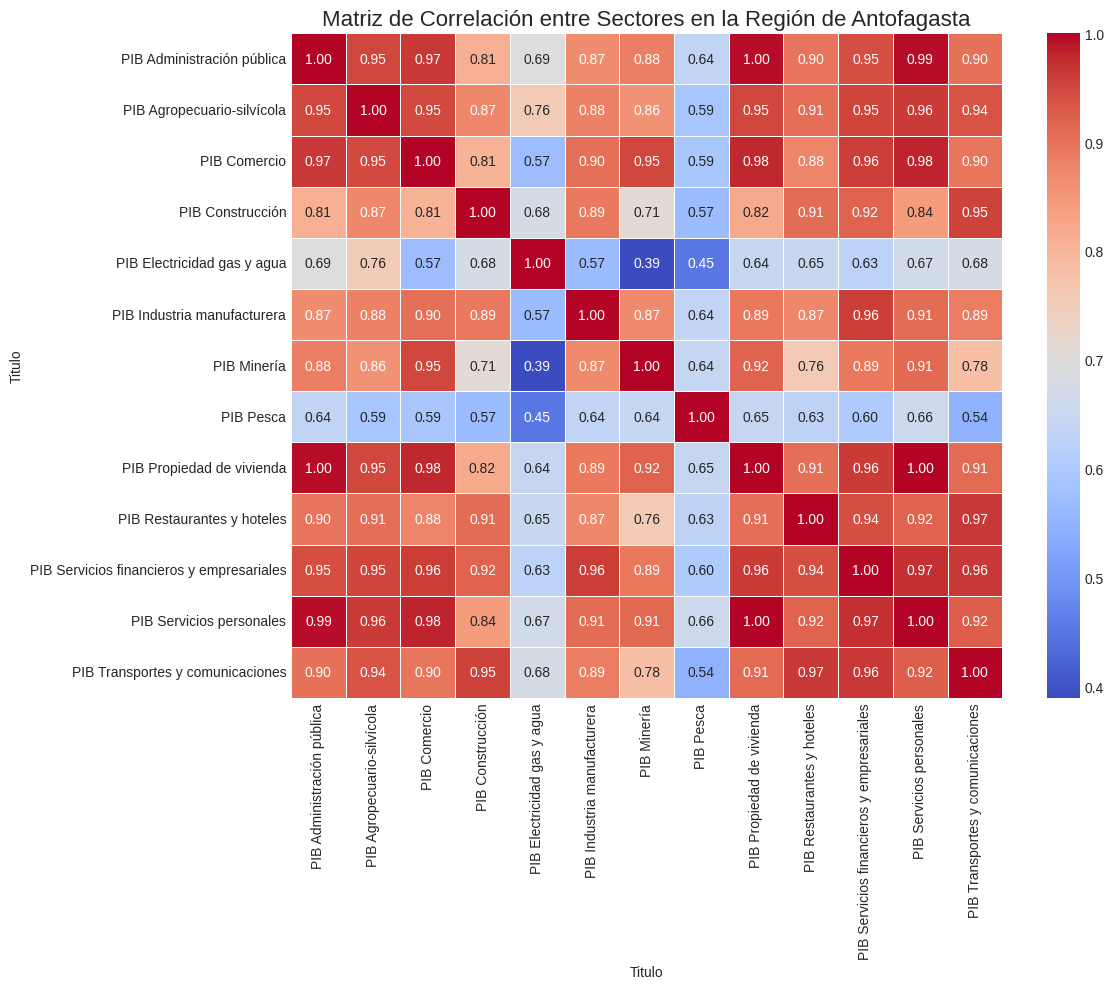

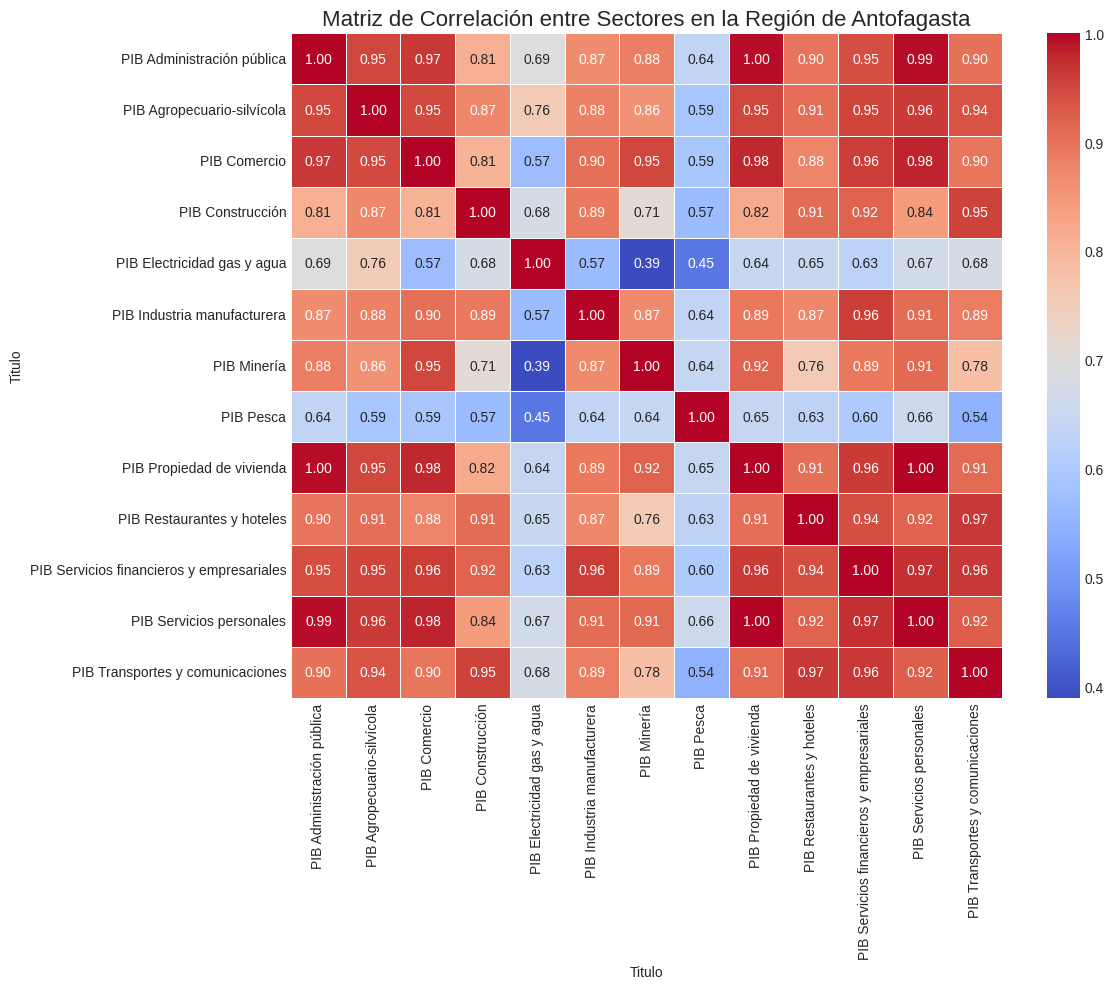

In [434]:
heatmap_correlacion(df_final_servicios, 'Antofagasta')

In [435]:
def grafico_covid_comparacion(df_comparison, region_name):
    """
    Genera visualizaciones para comparar el rendimiento pre y post-COVID de los sectores.

    Args:
        df_comparison (pd.DataFrame): DataFrame resultante de la función COVID_comparacion.
        region_name (str): Nombre de la región para el título del gráfico.
    """
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7), sharex=True)
    fig.suptitle(f'Comparación Pre vs Post-COVID para la Región de {region_name}', fontsize=20)

    # Plot 1: Diferencia en CAGR
    axes[0] = df_comparison['Diff CAGR'].plot(kind='bar', ax=axes[0], color=np.where(df_comparison['Diff CAGR'] > 0, 'green', 'red'))
    axes[0].set_title('Diferencia en Crecimiento Anual Compuesto (CAGR)', fontsize=14)
    axes[0].set_ylabel('Diff CAGR', fontsize=12)
    axes[0].tick_params(axis='x', rotation=90) # Align x-axis categories with bars
    axes[0].axhline(0, color='grey', linestyle='--')

    # Plot 2: Diferencia en Media
    axes[1] = df_comparison['Diff Media'].plot(kind='bar', ax=axes[1], color=np.where(df_comparison['Diff Media'] > 0, 'green', 'red'))
    axes[1].set_title('Diferencia en Media de Variación Interanual', fontsize=14)
    axes[1].set_ylabel('Diff Media', fontsize=12)
    axes[1].tick_params(axis='x', rotation=90) # Align x-axis categories with bars
    axes[1].axhline(0, color='grey', linestyle='--')

    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig # Return figure object for saving



In [436]:
df_pre, _, n_pre = Analisis_PIB(df_final_servicios,"Los Lagos","pre",'01-01-2020')
df_post, _, n_post = Analisis_PIB(df_final_servicios,"Los Lagos","post",'01-01-2020')

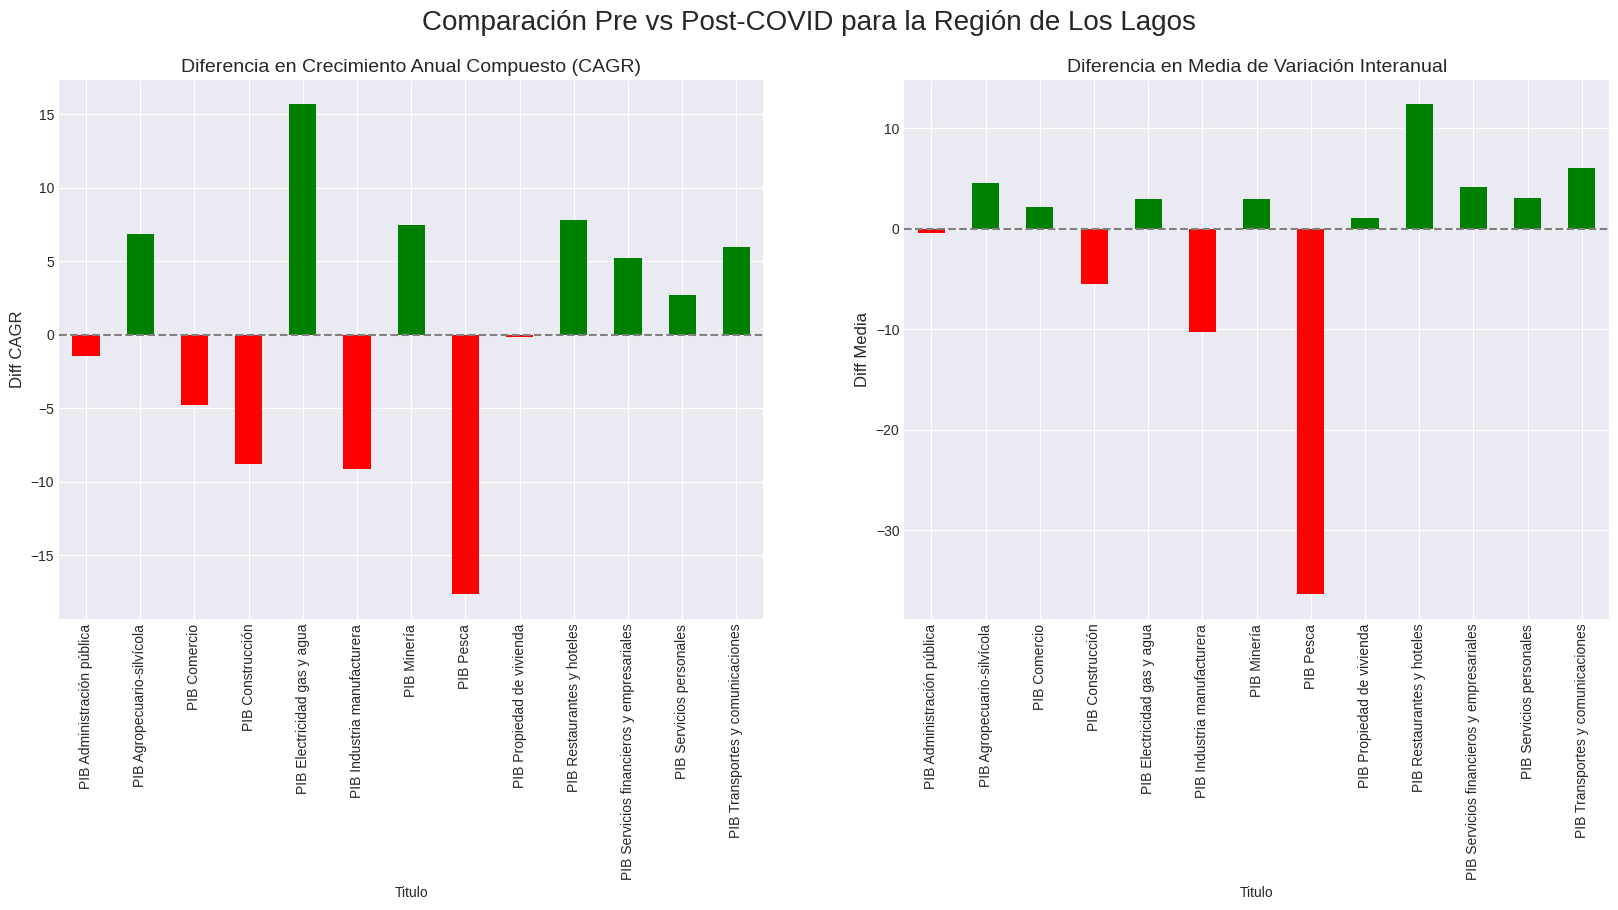

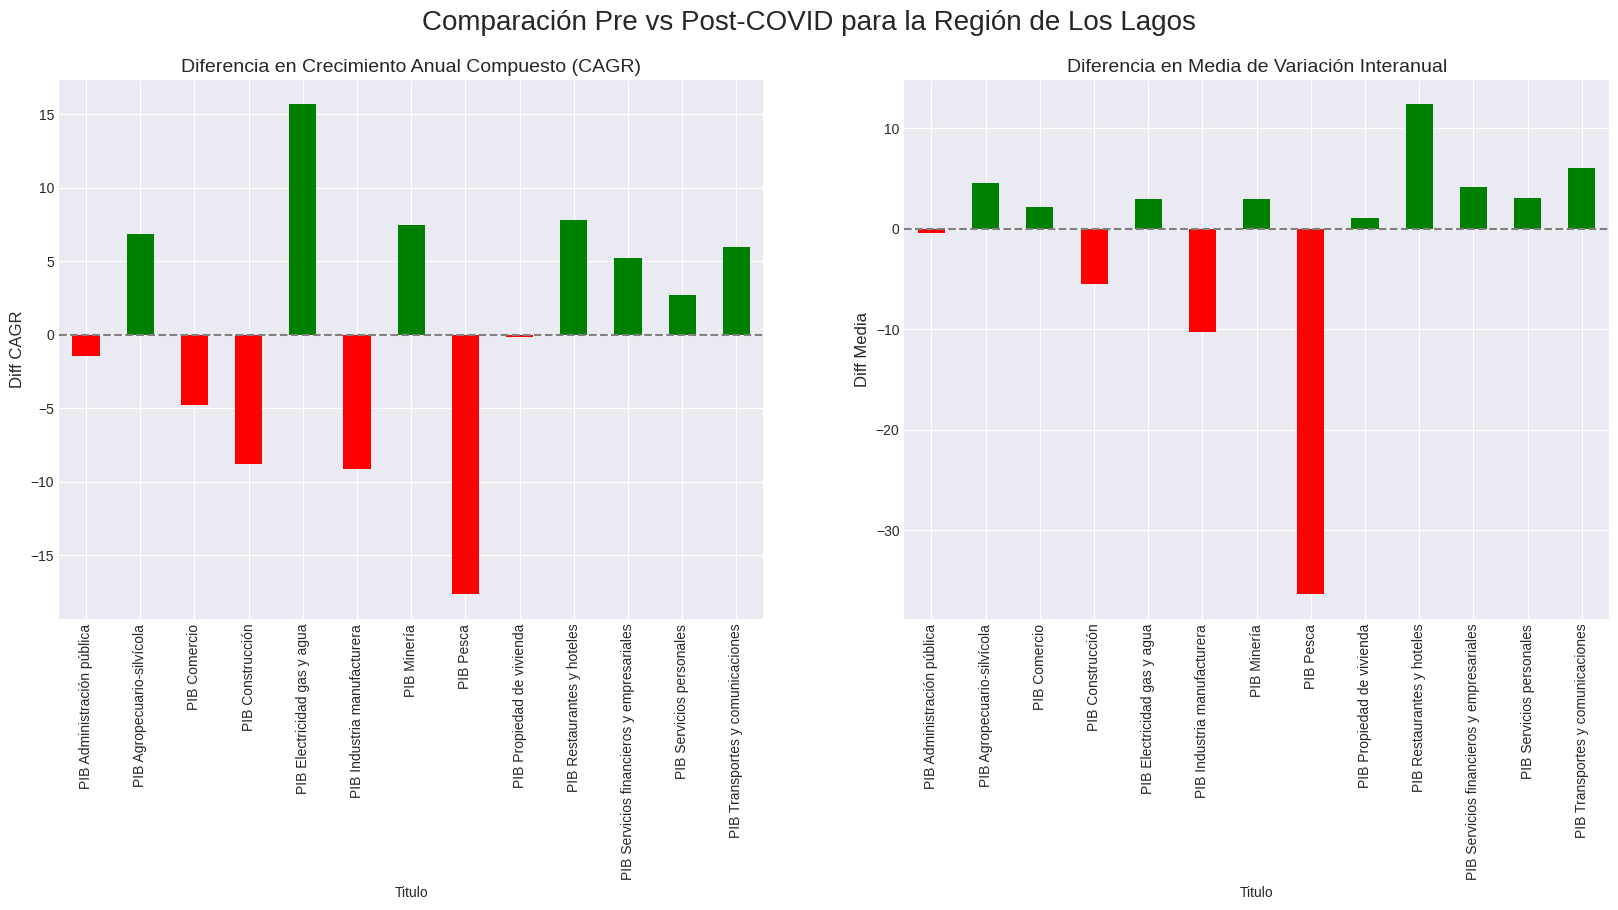

In [437]:
comparison_df_los_lagos = COVID_comparacion(df_pre, df_post, n_pre, n_post)
grafico_covid_comparacion(comparison_df_los_lagos, 'Los Lagos')

Para la función `grafico_covid_comparacion(df_pre, df_post)`, necesito los dataframes `df_pre` y `df_post` que se generaron en la sección de 'Análisis COVID'.

Para la función `mapa_calor_regional(df)`, sería ideal tener un archivo GeoJSON de las regiones de Chile para poder crear un mapa coroplético interactivo. Si no lo tienes, podemos explorar otras opciones o puedo indicarte cómo obtener uno.

In [438]:
import os

# Create output directory if it doesn't exist
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Re-generate and save grafico_evolucion_pib
fig1 = grafico_evolucion_pib(df_final_servicios, 'Antofagasta')
fig1.savefig(os.path.join(output_dir, 'evolucion_pib_antofagasta.png'))
plt.close(fig1) # Close the specific figure

# Re-generate and save heatmap_correlacion
fig2 = heatmap_correlacion(df_final_servicios, 'Antofagasta')
fig2.savefig(os.path.join(output_dir, 'heatmap_correlacion_antofagasta.png'))
plt.close(fig2)

# Re-generate and save grafico_covid_comparacion
comparison_df_los_lagos = COVID_comparacion(df_pre, df_post, n_pre, n_post)
fig3 = grafico_covid_comparacion(comparison_df_los_lagos, 'Los Lagos')
fig3.savefig(os.path.join(output_dir, 'covid_comparacion_los_lagos.png'))
plt.close(fig3)

print(f"Plots saved to the '{output_dir}' directory.")

Plots saved to the 'output' directory.


## Población

In [439]:
siete.buscar(lista_dataset[0]).spanishTitle.unique()

array(['Tasa de desocupación, hombres | Ajustada estacionalmente | INE | Mensual | Porcentaje',
       'Tasa de desocupación, mujeres | Ajustada estacionalmente | INE | Mensual | Porcentaje',
       'Tasa de desocupación, total | Ajustada estacionalmente | INE | Mensual | Porcentaje',
       'Tasa de desocupación, hombres | No Ajustada | INE | Mensual | Porcentaje',
       'Tasa de desocupación, mujeres | No Ajustada | INE | Mensual | Porcentaje',
       'Tasa de desocupación, total | No Ajustada | INE | Mensual | Porcentaje',
       'Tasa de desocupación, Región de Tarapacá, mensual INE',
       'Tasa de desocupación, Región de Antofagasta, mensual INE',
       'Tasa de desocupación, Región de Atacama, mensual INE',
       'Tasa de desocupación, Región de Coquimbo, mensual INE',
       'Tasa de desocupación, Región de Valparaíso, mensual INE',
       "Tasa de desocupación, Región del Libertador Gral. Bernardo O'Higgins, mensual INE",
       'Tasa de desocupación, Región del Maule, men

In [440]:
serie_desocupacion = siete.buscar(lista_dataset[0]) # Tasa de desempleo
serie_empleo = siete.buscar(lista_dataset[1]) #  Miles de personas

In [441]:
serie_desocupacion_mod = ajuste_df_serie(serie_desocupacion)
serie_empleo_mod = ajuste_df_serie(serie_empleo)


In [442]:
df_final_desempleo = datos_regionales(serie_desocupacion_mod)
df_final_empleo = datos_regionales(serie_empleo_mod) # Ya viene con solamente con regiones


In [443]:
df_final_desempleo[["Titulo","Sub"]] = df_final_desempleo["Titulo"].str.split("|",n=2,expand=True)[[0,1]]

In [444]:
df_final_desempleo_reg = df_final_desempleo[df_final_desempleo["Región"].isna() == False]

In [445]:
df_final_desempleo_reg.Región.unique() == df_final_empleo.Región.unique() #Mismo nombre de reionges? Si

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [446]:
df_final_empleo[df_final_empleo['Región'] == "Los lagos"].value

,value
0,337.385693
1,337.915254
2,342.665359
3,341.469397
4,336.991657
...,...
186,409.038323
187,408.073639
188,404.985129
189,406.263336


In [447]:
df_final_desempleo_reg[df_final_desempleo_reg['Región'] == "Los lagos"].value

,value
0,7.174488
1,7.120925
2,7.666831
3,8.626787
4,8.497949
...,...
186,5.493808
187,6.586342
188,6.815972
189,6.443209


In [448]:
df_final_desempleo_reg[df_final_desempleo_reg['Date'] == "2025-01-11"]

,Date,value,statusCode,Titulo,Región,Sub
188,2025-01-11,9.052228,OK,Tasa de desocupación,Tarapacá,None
188,2025-01-11,6.636536,OK,Tasa de desocupación,Antofagasta,None
188,2025-01-11,9.066061,OK,Tasa de desocupación,Atacama,None
188,2025-01-11,7.527107,OK,Tasa de desocupación,Coquimbo,None
188,2025-01-11,8.023588,OK,Tasa de desocupación,Valparaíso,None
188,2025-01-11,7.898955,OK,Tasa de desocupación,Del libertador gral. bernardo o'higgins,None
188,2025-01-11,7.665015,OK,Tasa de desocupación,Del maule,None
188,2025-01-11,9.877050,OK,Tasa de desocupación,Del biobío,None
188,2025-01-11,8.307204,OK,Tasa de desocupación,La araucanía,None
188,2025-01-11,6.815972,OK,Tasa de desocupación,Los lagos,None


In [449]:
siete.buscar("Población").spanishTitle.unique()

array(['Población de 15 años y más, mensual, INE (promedios móviles trimestrales, miles de personas)',
       'Población de 15 años y más, INE ',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 15 a 19 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 20 a 24 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 25 a 29 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 30 a 34 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género

#Exportar Datos


In [450]:
'''import json

reg = pd.read_json("cl.json")'''

'import json\n\nreg = pd.read_json("cl.json")'

In [451]:
'''for i in range(reg.shape[0]):
  print(reg["features"][i]["properties"]["name"])'''

'for i in range(reg.shape[0]):\n  print(reg["features"][i]["properties"]["name"])'

In [452]:
trans_reg = {
 'Del libertador general bernardo ohiggins':"Libertador General Bernardo O'Higgins",
 'Del maule':'Maule',
  'Del biobío':'Bío-Bío',
 'La araucanía':'La Araucanía',
 'Aysén del general carlos ibáñez del campo':'Aisén del General Carlos Ibáñez del Campo',
 'Magallanes y la antártica chilena':'Magallanes y Antártica Chilena',
 'Metropolitana santiago':'Región Metropolitana de Santiago',
 'Los ríos':'Los Ríos',
 'Arica y parinacota':'Arica y Parinacota',
 'Ñuble':'Ñuble'}

In [453]:
df_pib_export = df_anual[df_anual["Titulo"] == "PIB"]
df_pib_export["Región"] = df_pib_export["Región"].replace(trans_reg)
df_pib_export.to_csv('datos_pib.csv', index=False, encoding='utf-8')

/tmp/ipykernel_4994/499841875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pib_export["Región"] = df_pib_export["Región"].replace(trans_reg)


In [454]:
df_serv_export = df_anual[df_anual.Región.isna() == False]
df_serv_export = df_serv_export[df_serv_export["Titulo"] != "PIB"]
df_serv_export.Titulo = df_serv_export.Titulo.str.replace("PIB ","")
df_serv_export["Región"] = df_serv_export["Región"].replace(trans_reg)
df_serv_export.to_csv('datos_serv.csv', index=False, encoding='utf-8')

In [455]:
df_tendencia_export = pd.DataFrame(list_tendencia, columns=["Región","serv_actual","serv_tendencia","years"])
df_tendencia_export.serv_actual = df_tendencia_export.serv_actual.str.replace("PIB ","")
df_tendencia_export.serv_tendencia = df_tendencia_export.serv_tendencia.str.replace("PIB ","")

df_tendencia_export["Región"] = df_tendencia_export["Región"].replace(trans_reg)
df_tendencia_export.to_csv('datos_serv_tendencia.csv', index=False, encoding='utf-8')

In [456]:
df_anual.Región.unique()[0]

In [457]:
df_final_servicios["Región"].unique()

array(['Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo', 'Valparaíso',
       'Del libertador general bernardo ohiggins', 'Del maule',
       'Del biobío', 'La araucanía', 'Los lagos',
       'Aysén del general carlos ibáñez del campo',
       'Magallanes y la antártica chilena', 'Metropolitana santiago',
       'Los ríos', 'Arica y parinacota', 'Del ñuble'], dtype=object)